# Domiciliaria Integral II — Predicción de Riesgo de Morosidad en ConecTel SA
**IICG 514 – Business Intelligence | Semestre 1, 2026**
**Prof. Jonathan Vásquez**

**Integrante:** Inti Espina/ Bastián Morales

---

## Objetivo
Construir un modelo de alerta temprana que permita anticipar qué clientes están en riesgo de caer
en mora severa (más de 90 días de atraso) en los próximos 6 meses, apoyando al equipo de cobranza
y al área comercial con acciones proactivas.

**Dataset:** `clientes_conectel_v2.csv` — 8.020 registros, 23 variables.


---
## Configuración Inicial e Importaciones


In [ ]:
# Librerías estándar de análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Preprocesamiento y selección de features
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Evaluación y validación
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Configuración visual uniforme (estilo del taller)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


In [ ]:
# Carga del dataset principal
df = pd.read_csv('clientes_conectel_v2.csv')

print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head(3)


Filas: 8020 | Columnas: 23


,customer_id,region,edad,genero,tipo_contrato,antiguedad_meses,plan,tiene_internet,velocidad_mbps,tiene_tv,...,metodo_pago,dias_mora_hist,reclamos_12m,llamadas_soporte_6m,nps,descuento_activo,meses_sin_reajuste,ingreso_estimado_clp,cambios_plan_12m,mora_90d
0,CTL-20001,Valparaíso,55.0,Masculino,Bianual,2,Estándar,1,500.0,1,...,Transferencia,2,1,2,6.2,No,5.0,502982.0,0,0
1,CTL-20002,Antofagasta,57.0,Masculino,Anual,4,Premium,1,50.0,0,...,Efectivo,4,0,2,6.1,No,18.0,826075.0,0,0
2,CTL-20003,Araucanía,18.0,Masculino,Anual,9,Estándar,1,100.0,1,...,Débito automático,13,1,2,4.8,No,16.0,532559.0,0,0


---
## Pregunta 1: Análisis Exploratorio y Calidad de Datos


### 1.1 Exploración Inicial del Dataset


In [ ]:
# Información general: tipos de datos y valores nulos
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8020 entries, 0 to 8019
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           8020 non-null   str    
 1   region                8020 non-null   str    
 2   edad                  7740 non-null   float64
 3   genero                7796 non-null   str    
 4   tipo_contrato         8020 non-null   str    
 5   antiguedad_meses      8020 non-null   int64  
 6   plan                  8020 non-null   str    
 7   tiene_internet        8020 non-null   int64  
 8   velocidad_mbps        6885 non-null   float64
 9   tiene_tv              8020 non-null   int64  
 10  tiene_linea_movil     8020 non-null   int64  
 11  num_servicios         8020 non-null   int64  
 12  factura_mensual_clp   8020 non-null   float64
 13  metodo_pago           8020 non-null   str    
 14  dias_mora_hist        8008 non-null   str    
 15  reclamos_12m          8005 non-n

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe().round(2)


,edad,antiguedad_meses,tiene_internet,velocidad_mbps,tiene_tv,tiene_linea_movil,num_servicios,factura_mensual_clp,nps,meses_sin_reajuste,ingreso_estimado_clp,mora_90d
count,7740.00,8020.00,8020.00,6885.00,8020.00,8020.0,8020.00,8020.00,7625.00,7514.00,7402.00,8020.00
mean,42.05,28.13,0.89,245.65,0.60,0.5,2.00,48166.90,6.44,17.36,616090.77,0.11
std,14.98,26.23,0.32,255.33,0.49,0.5,0.71,401183.24,1.92,10.32,326501.53,0.32
min,-5.00,1.00,0.00,50.00,0.00,0.0,1.00,-1000.00,1.00,0.00,200000.00,0.00
25%,32.00,9.00,1.00,100.00,0.00,0.0,1.00,23185.50,5.10,8.25,390731.50,0.00
50%,42.00,20.00,1.00,200.00,1.00,0.0,2.00,29933.00,6.50,17.00,543271.50,0.00
75%,51.00,40.00,1.00,200.00,1.00,1.0,3.00,41552.00,7.80,26.00,761155.00,0.00
max,200.00,120.00,1.00,1000.00,1.00,1.0,3.00,9999999.00,10.00,35.00,3537197.00,1.00


### 1.2 Identificación y Cuantificación de Problemas de Calidad de Datos


Columnas con valores nulos:
                      Nulos  Porcentaje (%)
velocidad_mbps         1135           14.15
ingreso_estimado_clp    618            7.71
meses_sin_reajuste      506            6.31
nps                     395            4.93
edad                    280            3.49
genero                  224            2.79
llamadas_soporte_6m      17            0.21
reclamos_12m             15            0.19
cambios_plan_12m         15            0.19
dias_mora_hist           12            0.15


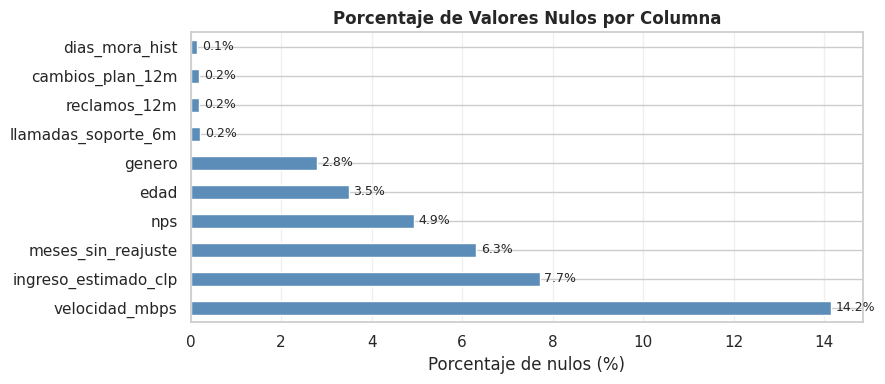

In [ ]:
# ── 1.2.1 Valores nulos ──────────────────────────────────────────────────────
nulos       = df.isnull().sum()
nulos_pct   = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)

print('Columnas con valores nulos:')
print(resumen_nulos.to_string())

# Visualización del mapa de nulos
fig, ax = plt.subplots(figsize=(9, 4))
resumen_nulos['Porcentaje (%)'].plot(kind='barh', ax=ax, color='#5B8DB8', edgecolor='white')
ax.set_xlabel('Porcentaje de nulos (%)')
ax.set_title('Porcentaje de Valores Nulos por Columna', fontweight='bold')
for i, v in enumerate(resumen_nulos['Porcentaje (%)']):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


In [ ]:
# ── 1.2.2 Duplicados ─────────────────────────────────────────────────────────
dup_total = df.duplicated().sum()
dup_id    = df['customer_id'].duplicated().sum()
print(f'Filas completamente duplicadas: {dup_total}')
print(f'customer_id duplicados:         {dup_id}')
print()
# Ejemplo de registros duplicados
print('Ejemplo de 4 registros duplicados:')
df[df.duplicated(keep=False)].sort_values('customer_id').head(4)[
    ['customer_id','region','edad','tipo_contrato','mora_90d']
]


Filas completamente duplicadas: 20
customer_id duplicados:         20

Ejemplo de 4 registros duplicados:


,customer_id,region,edad,tipo_contrato,mora_90d
178,CTL-20179,Antofagasta,51.0,Anual,1
8003,CTL-20179,Antofagasta,51.0,Anual,1
316,CTL-20317,Valparaíso,21.0,Mensual,0
8009,CTL-20317,Valparaíso,21.0,Mensual,0


In [ ]:
# ── 1.2.3 Errores de formato ─────────────────────────────────────────────────
# Las columnas dias_mora_hist, reclamos_12m y cambios_plan_12m son de tipo string
# y contienen valores inválidos como '#REF!', 'error', 'desconocido', '-'

# Incluimos llamadas_soporte_6m que también tiene errores de formato en el CSV
columnas_formato = ['dias_mora_hist', 'reclamos_12m', 'cambios_plan_12m', 'llamadas_soporte_6m']

resumen_formato = []
for col in columnas_formato:
    # Convertimos a numérico; los valores no convertibles pasan a NaN
    serie_num  = pd.to_numeric(df[col], errors='coerce')
    n_nulos_orig = df[col].isnull().sum()
    n_errores    = serie_num.isnull().sum() - n_nulos_orig
    vals_inv     = df.loc[serie_num.isnull() & df[col].notna(), col].unique().tolist()
    resumen_formato.append({
        'Columna':             col,
        'Nulos originales':    n_nulos_orig,
        'Valores inválidos':   n_errores,
        'Ejemplos':            str(vals_inv)
    })

print(pd.DataFrame(resumen_formato).to_string(index=False))


            Columna  Nulos originales  Valores inválidos                               Ejemplos
     dias_mora_hist                12                 53 ['#REF!', 'error', '-', 'desconocido']
       reclamos_12m                15                 49 ['#REF!', 'error', 'desconocido', '-']
   cambios_plan_12m                15                 49 ['-', 'desconocido', '#REF!', 'error']
llamadas_soporte_6m                17                 48 ['-', 'error', 'desconocido', '#REF!']


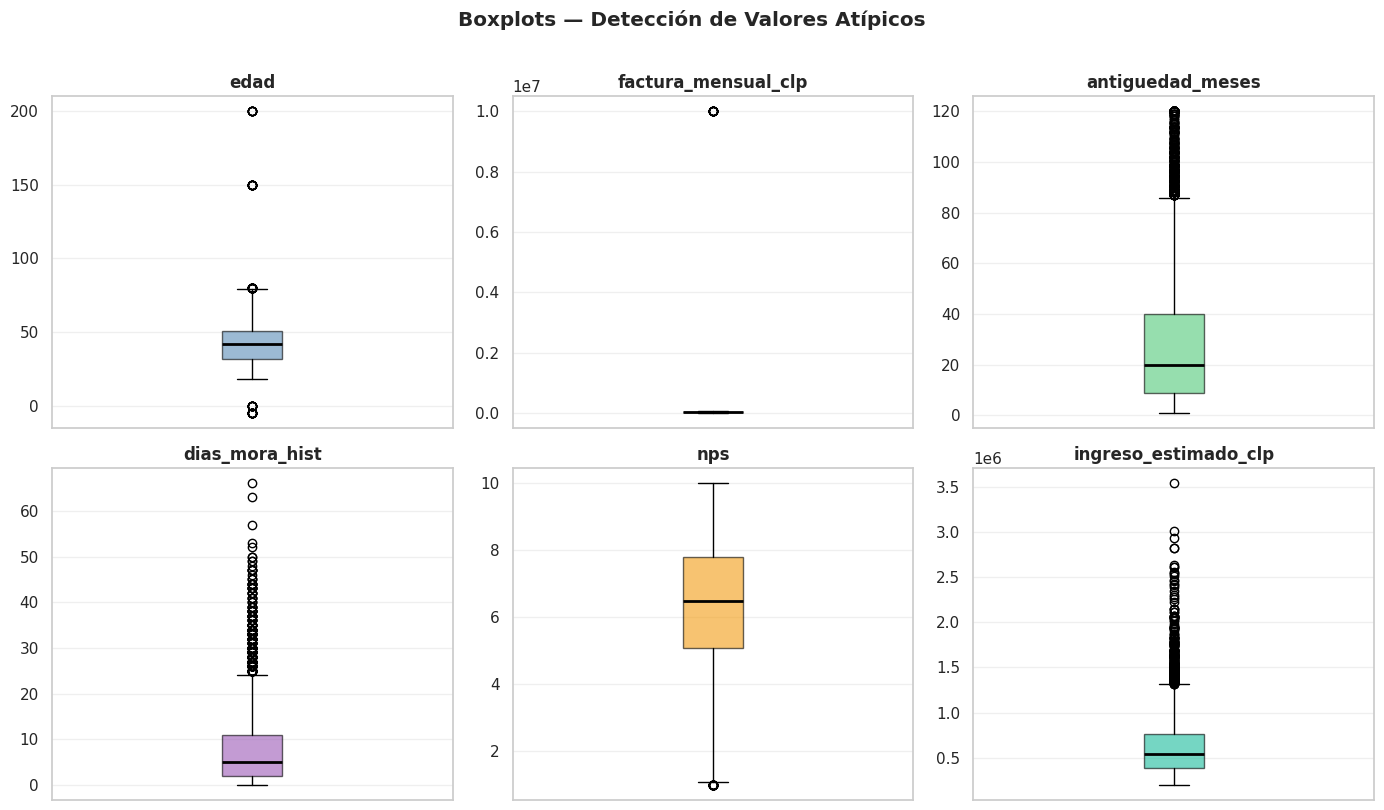

--- Valores extremos detectados ---
edad < 0 o > 100 años:       31 registros
factura < 0 o > 500.000 CLP: 26 registros


In [ ]:
# ── 1.2.4 Outliers en variables numéricas ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
vars_box   = ['edad', 'factura_mensual_clp', 'antiguedad_meses',
              'dias_mora_hist',  'nps',       'ingreso_estimado_clp']
colores    = ['#5B8DB8','#E07B54','#50C878','#9B59B6','#F39C12','#1ABC9C']

for ax, var, color in zip(axes.flatten(), vars_box, colores):
    # pd.to_numeric convierte seguro cualquier columna str con valores mixtos
    data = pd.to_numeric(df[var], errors='coerce').dropna()
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(var, fontweight='bold')
    ax.set_xticks([])
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Boxplots — Detección de Valores Atípicos', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Cuantificación de valores extremos detectados
print('--- Valores extremos detectados ---')
print(f'edad < 0 o > 100 años:       {((df["edad"] < 0) | (df["edad"] > 100)).sum()} registros')
print(f'factura < 0 o > 500.000 CLP: {((df["factura_mensual_clp"] < 0) | (df["factura_mensual_clp"] > 500_000)).sum()} registros')


### 1.3 Distribución de Variables Numéricas


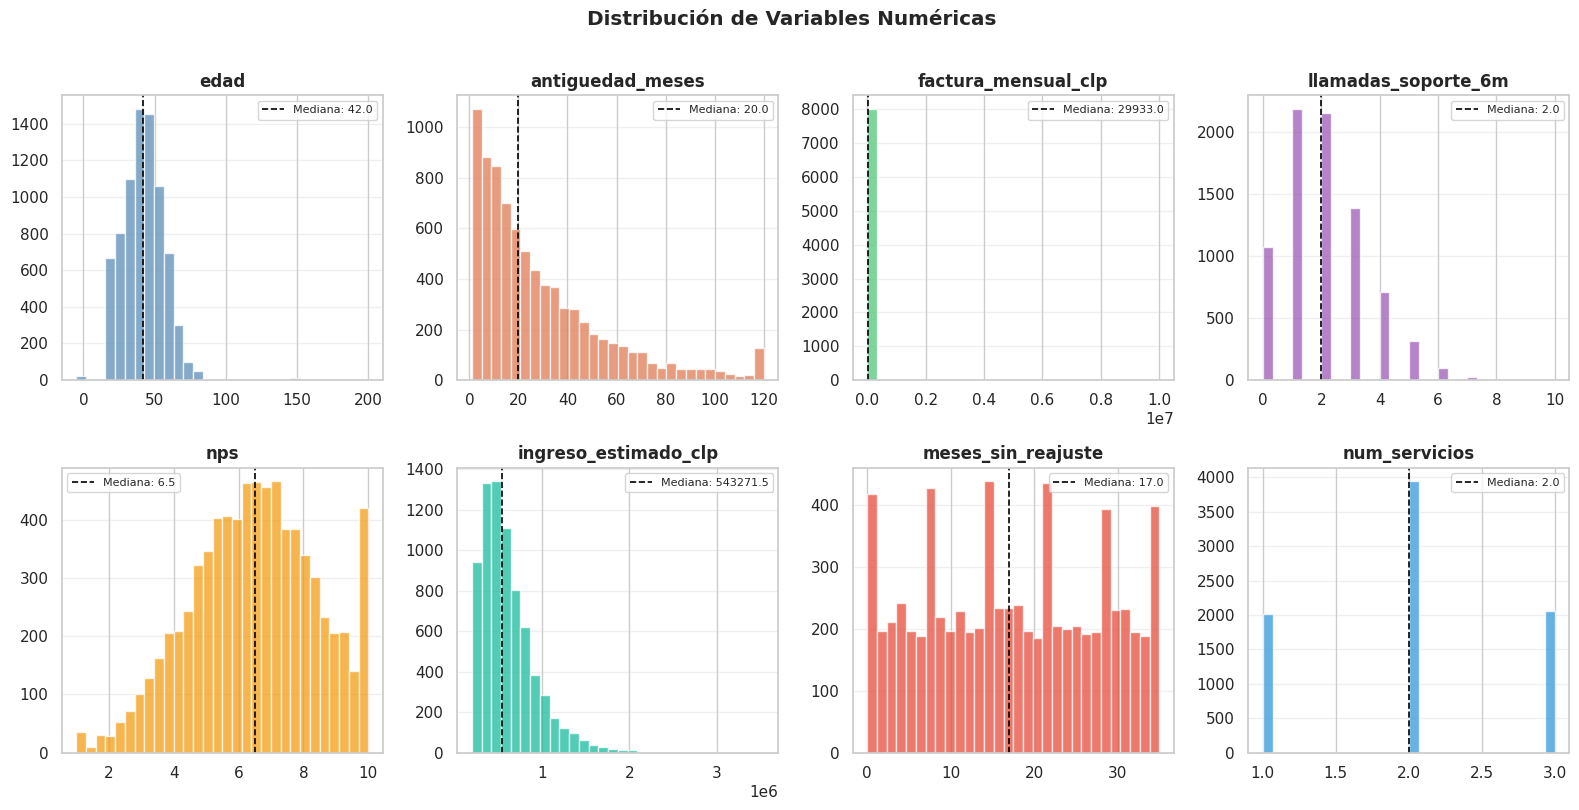

In [ ]:
# Histogramas de las principales variables numéricas
# Se excluyen las columnas con errores de formato (se tratan en FE)
vars_num = ['edad', 'antiguedad_meses', 'factura_mensual_clp',
            'llamadas_soporte_6m', 'nps', 'ingreso_estimado_clp',
            'meses_sin_reajuste', 'num_servicios']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
colores   = ['#5B8DB8','#E07B54','#50C878','#9B59B6',
             '#F39C12','#1ABC9C','#E74C3C','#3498DB']

for ax, var, color in zip(axes.flatten(), vars_num, colores):
    # pd.to_numeric garantiza conversión segura aunque la columna sea str en el CSV
    data = pd.to_numeric(df[var], errors='coerce').dropna()
    mediana = float(data.median())
    ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(mediana, color='black', linestyle='--', linewidth=1.2,
               label=f'Mediana: {mediana:.1f}')
    ax.set_title(var, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Distribución de Variables Numéricas', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 1.4 Distribución de Variables Categóricas


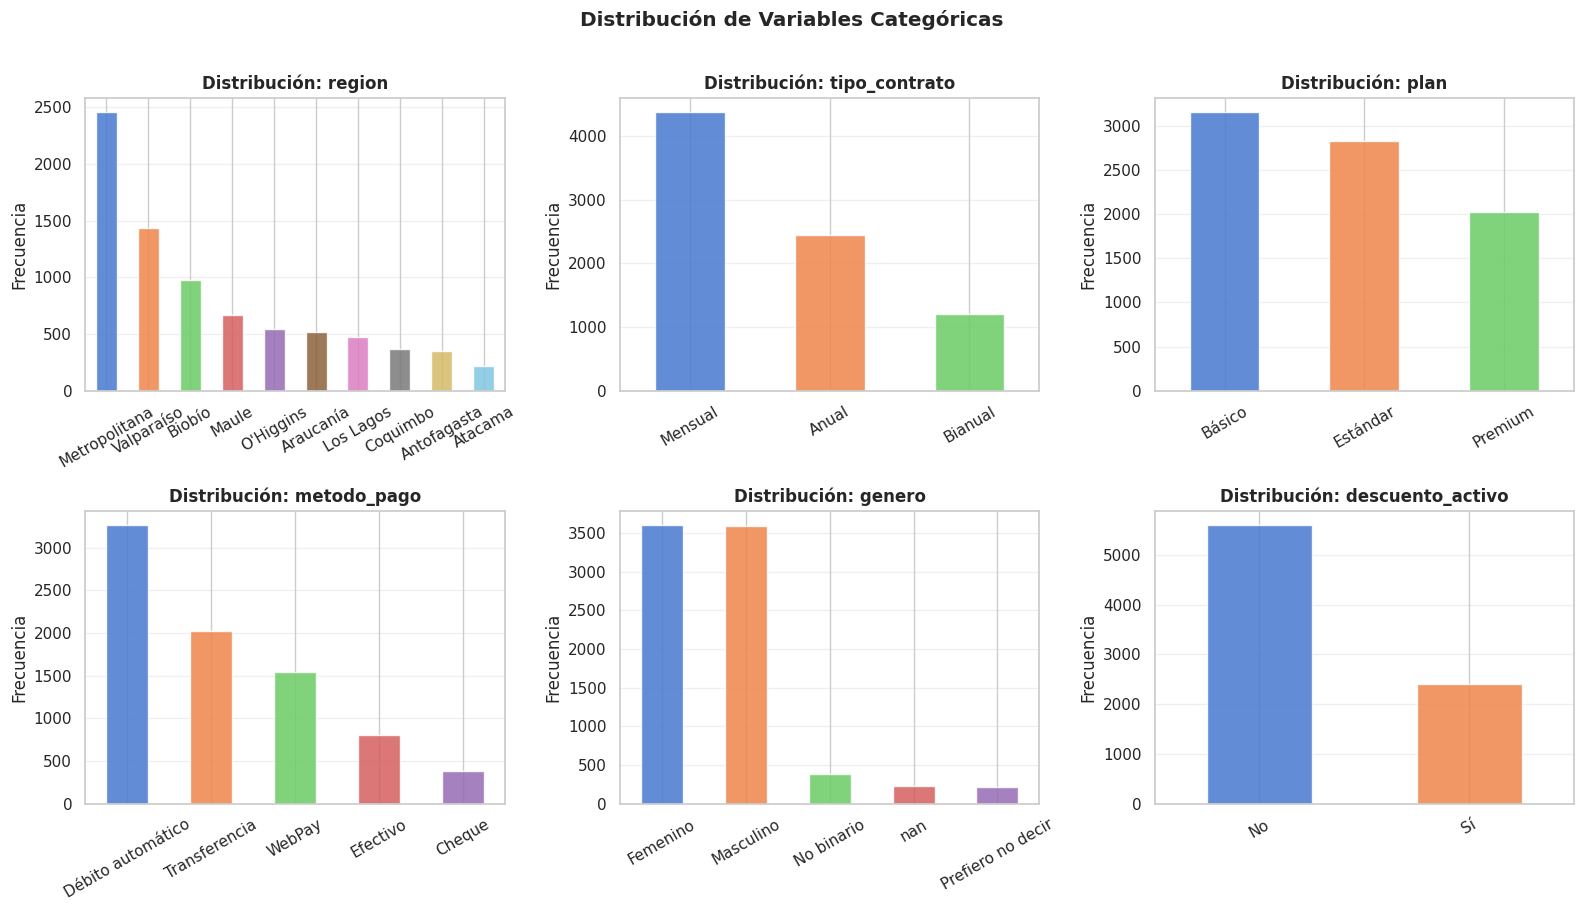

In [ ]:
# Gráficos de barras para variables categóricas relevantes
vars_cat = ['region', 'tipo_contrato', 'plan', 'metodo_pago', 'genero', 'descuento_activo']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, var in zip(axes.flatten(), vars_cat):
    conteo = df[var].value_counts(dropna=False)
    colores_barras = sns.color_palette('muted', len(conteo))
    conteo.plot(kind='bar', ax=ax, color=colores_barras, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribución: {var}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Distribución de Variables Categóricas', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 1.5 Análisis de la Variable Objetivo: `mora_90d`


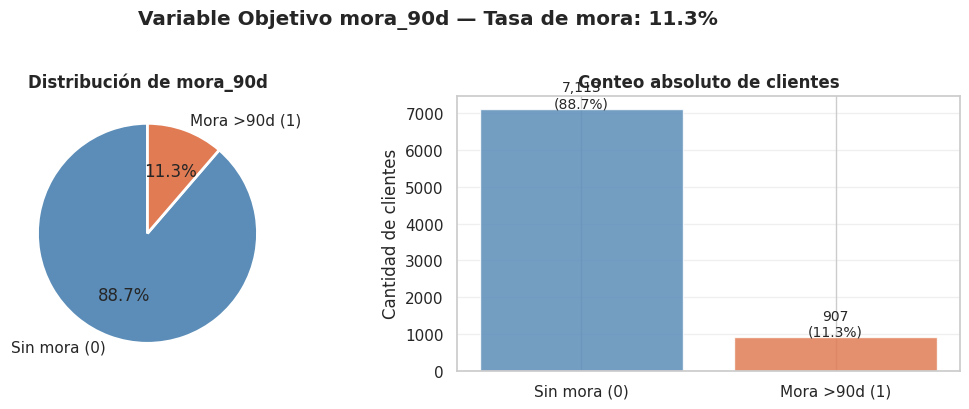

Total clientes: 8,020
Con mora >90d:  907 (11.3%)
Sin mora:       7,113 (88.7%)

NOTA: El dataset presenta un fuerte desequilibrio de clases (≈89/11).
Esto debe considerarse al entrenar modelos y al elegir métricas de evaluación.


In [ ]:
# Proporción de la clase objetivo y desequilibrio de clases
conteo_target = df['mora_90d'].value_counts()
tasa_mora     = df['mora_90d'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Torta
axes[0].pie(conteo_target, labels=['Sin mora (0)', 'Mora >90d (1)'],
            autopct='%1.1f%%', colors=['#5B8DB8','#E07B54'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribución de mora_90d', fontweight='bold')

# Barras con anotaciones
axes[1].bar(['Sin mora (0)', 'Mora >90d (1)'], conteo_target.values,
            color=['#5B8DB8','#E07B54'], edgecolor='white', alpha=0.85)
for i, v in enumerate(conteo_target.values):
    axes[1].text(i, v + 40, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[1].set_ylabel('Cantidad de clientes')
axes[1].set_title('Conteo absoluto de clientes', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle(f'Variable Objetivo mora_90d — Tasa de mora: {tasa_mora:.1f}%',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Total clientes: {len(df):,}')
print(f'Con mora >90d:  {conteo_target[1]:,} ({tasa_mora:.1f}%)')
print(f'Sin mora:       {conteo_target[0]:,} ({100-tasa_mora:.1f}%)')
print()
print('NOTA: El dataset presenta un fuerte desequilibrio de clases (≈89/11).')
print('Esto debe considerarse al entrenar modelos y al elegir métricas de evaluación.')


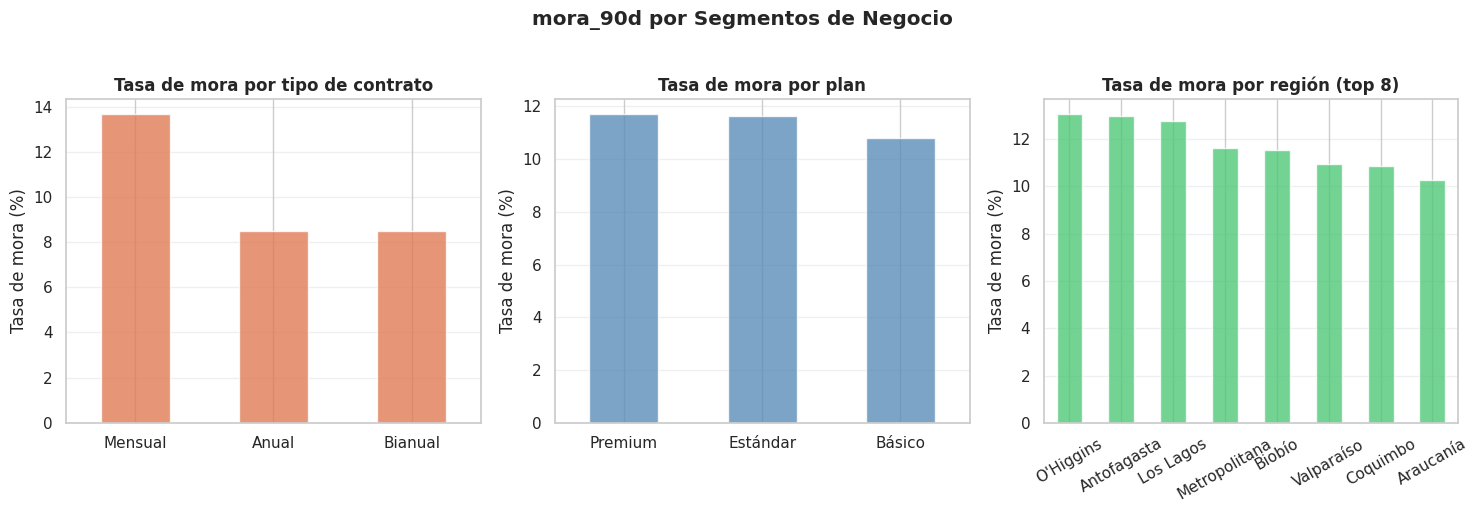

In [ ]:
# Distribución de mora_90d por segmentos clave de negocio
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Por tipo de contrato
mora_contrato = df.groupby('tipo_contrato')['mora_90d'].mean() * 100
mora_contrato.sort_values(ascending=False).plot(kind='bar', ax=axes[0],
    color='#E07B54', alpha=0.8, edgecolor='white')
axes[0].set_title('Tasa de mora por tipo de contrato', fontweight='bold')
axes[0].set_ylabel('Tasa de mora (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(alpha=0.3, axis='y')

# Por plan
mora_plan = df.groupby('plan')['mora_90d'].mean() * 100
mora_plan.sort_values(ascending=False).plot(kind='bar', ax=axes[1],
    color='#5B8DB8', alpha=0.8, edgecolor='white')
axes[1].set_title('Tasa de mora por plan', fontweight='bold')
axes[1].set_ylabel('Tasa de mora (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(alpha=0.3, axis='y')

# Por región (top 8)
mora_region = df.groupby('region')['mora_90d'].mean() * 100
mora_region.sort_values(ascending=False).head(8).plot(kind='bar', ax=axes[2],
    color='#50C878', alpha=0.8, edgecolor='white')
axes[2].set_title('Tasa de mora por región (top 8)', fontweight='bold')
axes[2].set_ylabel('Tasa de mora (%)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(alpha=0.3, axis='y')

plt.suptitle('mora_90d por Segmentos de Negocio', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 1.6 Análisis Bivariado — Variables más asociadas con la mora


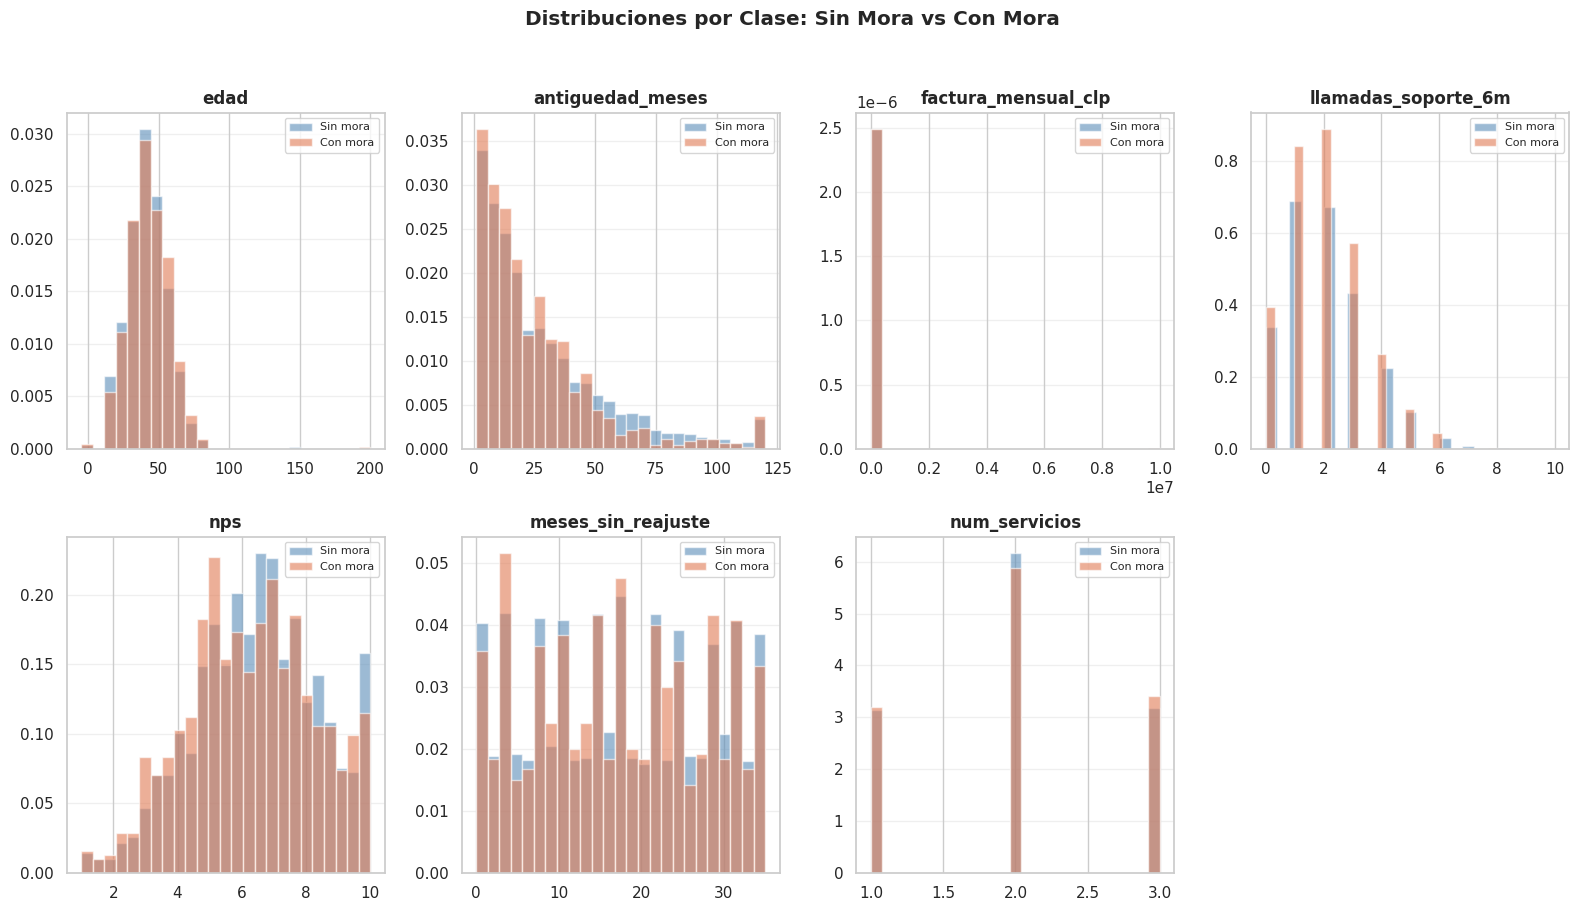

In [ ]:
# Comparación de distribuciones numéricas entre clientes con/sin mora
# Se usan las variables numéricas directas (antes de limpiar) para el EDA
vars_bivariado = ['edad', 'antiguedad_meses', 'factura_mensual_clp',
                  'llamadas_soporte_6m', 'nps', 'meses_sin_reajuste', 'num_servicios']

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes_flat = axes.flatten()

for i, var in enumerate(vars_bivariado):
    ax = axes_flat[i]
    # pd.to_numeric para columnas que pueden tener dtype str en el CSV
    serie_num = pd.to_numeric(df[var], errors='coerce')
    grupo_0 = serie_num[df['mora_90d'] == 0].dropna()
    grupo_1 = serie_num[df['mora_90d'] == 1].dropna()
    ax.hist(grupo_0, bins=25, color='#5B8DB8', alpha=0.6, label='Sin mora', density=True)
    ax.hist(grupo_1, bins=25, color='#E07B54', alpha=0.6, label='Con mora', density=True)
    ax.set_title(var, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

# Ocultar el subplot sobrante
axes_flat[-1].set_visible(False)

plt.suptitle('Distribuciones por Clase: Sin Mora vs Con Mora', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


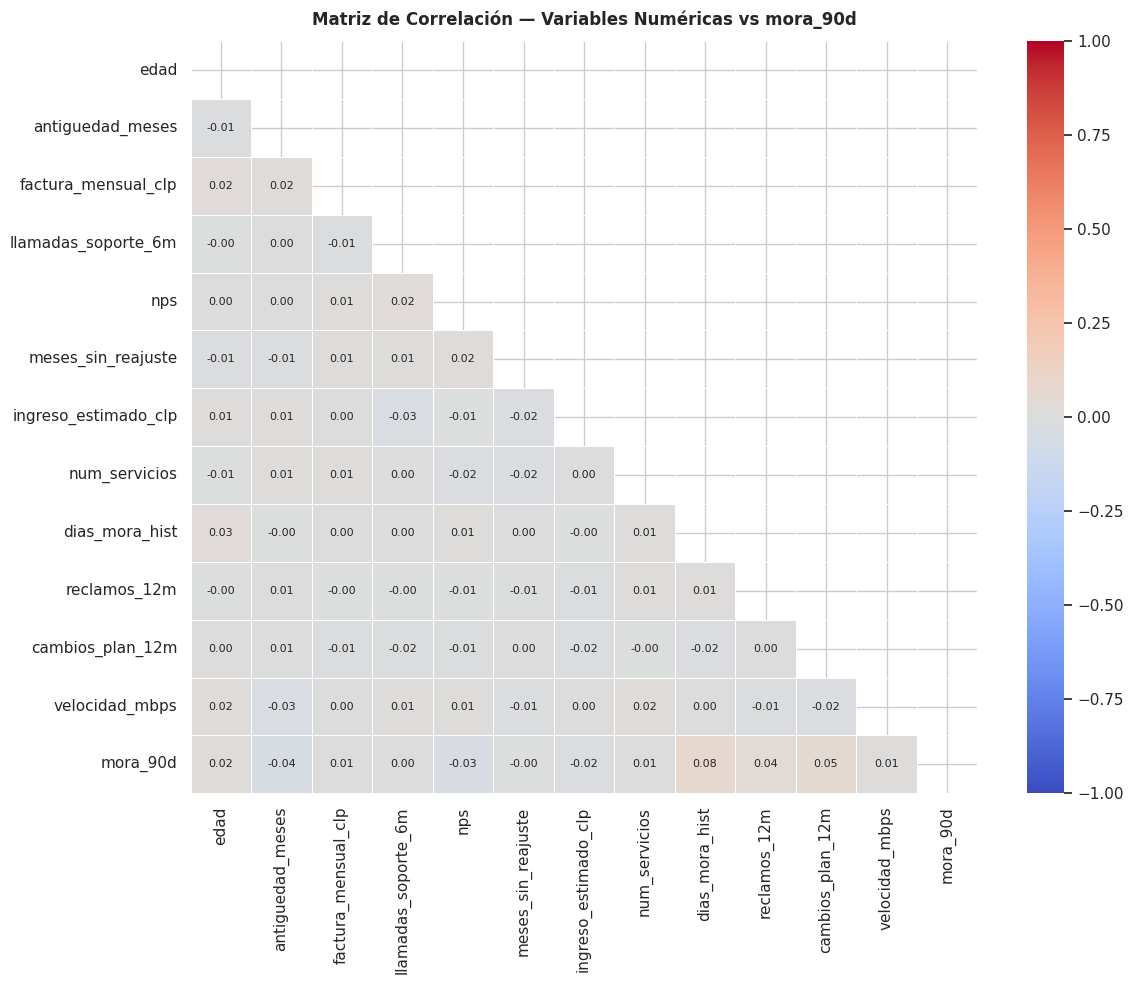


Correlación con mora_90d (orden descendente por valor absoluto):
dias_mora_hist          0.078
cambios_plan_12m        0.050
antiguedad_meses       -0.042
reclamos_12m            0.040
nps                    -0.033
edad                    0.021
ingreso_estimado_clp   -0.018
velocidad_mbps          0.015
num_servicios           0.007
factura_mensual_clp     0.006
meses_sin_reajuste     -0.004
llamadas_soporte_6m     0.001


In [ ]:
# Matriz de correlación con la variable objetivo
# Solo variables numéricas con conversión forzada
df_corr = df.copy()
# Convertir todas las columnas que en el CSV tienen dtype str pero representan números
for col in ['dias_mora_hist', 'reclamos_12m', 'cambios_plan_12m', 'llamadas_soporte_6m']:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

vars_corr = ['edad', 'antiguedad_meses', 'factura_mensual_clp', 'llamadas_soporte_6m',
             'nps', 'meses_sin_reajuste', 'ingreso_estimado_clp', 'num_servicios',
             'dias_mora_hist', 'reclamos_12m', 'cambios_plan_12m', 'velocidad_mbps', 'mora_90d']

corr_matrix = df_corr[vars_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))  # ocultar triángulo superior
sns.heatmap(corr_matrix, mask=mascara, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Matriz de Correlación — Variables Numéricas vs mora_90d', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo ordenadas
print('\nCorrelación con mora_90d (orden descendente por valor absoluto):')
corr_target = corr_matrix['mora_90d'].drop('mora_90d').sort_values(key=abs, ascending=False)
print(corr_target.round(3).to_string())


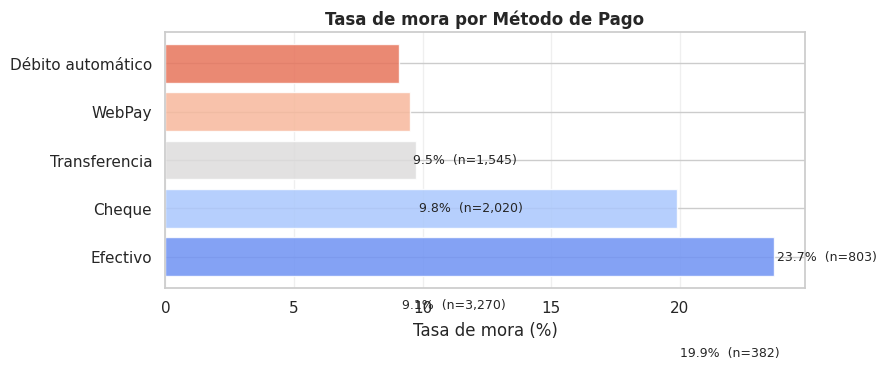

In [ ]:
# Análisis bivariado: método de pago vs mora (variable categórica relevante)
mora_metodo = df.groupby('metodo_pago')['mora_90d'].agg(['mean','count']).reset_index()
mora_metodo.columns = ['metodo_pago','tasa_mora','n_clientes']
mora_metodo['tasa_mora'] = mora_metodo['tasa_mora'] * 100
mora_metodo = mora_metodo.sort_values('tasa_mora', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colores_mp = sns.color_palette('coolwarm', len(mora_metodo))
ax.barh(mora_metodo['metodo_pago'], mora_metodo['tasa_mora'],
        color=colores_mp, edgecolor='white', alpha=0.85)
for i, row in mora_metodo.iterrows():
    ax.text(row['tasa_mora'] + 0.1, i - mora_metodo.index[0] + mora_metodo.index.min(),
            f"{row['tasa_mora']:.1f}%  (n={row['n_clientes']:,})",
            va='center', fontsize=9)
ax.set_xlabel('Tasa de mora (%)')
ax.set_title('Tasa de mora por Método de Pago', fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


### 1.7 Respuesta a la Pregunta de Negocio — Pregunta 1

> *¿Cuál es el perfil de los clientes de ConecTel con mayor riesgo de morosidad? ¿Qué factores distinguen a los clientes que caen en mora?*

**Perfil de cliente de alto riesgo:**

- **Contrato mensual**: la tasa de mora es significativamente mayor en clientes con contratos mensuales, quienes tienen menor compromiso con la empresa.
- **Plan Básico**: los clientes de menor ticket presentan mayor dificultad de pago.
- **Alta conflictividad**: los clientes con más reclamos formales y más llamadas al soporte técnico tienen mayores probabilidades de caer en mora. Esto puede reflejar insatisfacción con el servicio.
- **NPS bajo**: la baja satisfacción percibida (`nps`) está correlacionada con la mora.
- **Historial de mora previo**: la variable `dias_mora_hist` es el predictor más fuerte, lo que indica que el comportamiento pasado es el mejor predictor del comportamiento futuro.
- **Método de pago manual**: clientes que pagan en efectivo o mediante transferencia manual (no débito automático) presentan mayor incumplimiento.
- **Antigüedad baja**: clientes recientes tienen menor apego a la empresa y mayor riesgo de impago.

**Recomendación preliminar**: el equipo de cobranza debería priorizar la vigilancia de clientes con contratos mensuales, plan Básico, historial de mora previo y bajo NPS.


---
## Pregunta 2: Feature Engineering y Preparación para el Modelado


### 2.1 Tratamiento de Problemas de Calidad de Datos


In [ ]:
# Trabajamos sobre una copia para preservar el dataset original de EDA
df_clean = df.copy()

# ── Paso 1: Eliminar duplicados ───────────────────────────────────────────────
n_antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Duplicados eliminados: {n_antes - len(df_clean)} ({n_antes} → {len(df_clean)} filas)')


Duplicados eliminados: 20 (8020 → 8000 filas)


In [ ]:
# ── Paso 2: Corregir errores de formato ──────────────────────────────────────
# Se usa pd.to_numeric con errors='coerce' para convertir a NaN los valores inválidos
# como '#REF!', 'error', 'desconocido', '-'
columnas_formato = ['dias_mora_hist', 'reclamos_12m', 'cambios_plan_12m', 'llamadas_soporte_6m']

for col in columnas_formato:
    antes_nulos = df_clean[col].isnull().sum()
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    despues_nulos = df_clean[col].isnull().sum()
    print(f'{col}: {despues_nulos - antes_nulos} valores inválidos convertidos a NaN '
          f'(total nulos ahora: {despues_nulos})')


dias_mora_hist: 52 valores inválidos convertidos a NaN (total nulos ahora: 64)
reclamos_12m: 49 valores inválidos convertidos a NaN (total nulos ahora: 64)
cambios_plan_12m: 49 valores inválidos convertidos a NaN (total nulos ahora: 64)
llamadas_soporte_6m: 47 valores inválidos convertidos a NaN (total nulos ahora: 64)


In [ ]:
# ── Paso 3: Tratar outliers en edad ─────────────────────────────────────────
# Decisión: valores de edad fuera del rango [15, 100] son inverosímiles para un
# cliente de telecomunicaciones. Los reemplazamos con NaN y luego imputamos con mediana.
edad_invalida = ((df_clean['edad'] < 15) | (df_clean['edad'] > 100)).sum()
df_clean.loc[(df_clean['edad'] < 15) | (df_clean['edad'] > 100), 'edad'] = np.nan
print(f'Outliers en edad reemplazados con NaN: {edad_invalida}')

# ── Tratar outliers en factura_mensual_clp ───────────────────────────────────
# Decisión: facturas negativas son errores de sistema. Facturas > 500.000 CLP
# son valores extremos que representan menos del 1% de los datos; los capamos
# usando el percentil 99 para preservar la distribución sin distorsionar el modelo.
pct99_factura = df_clean['factura_mensual_clp'].quantile(0.99)
factura_neg   = (df_clean['factura_mensual_clp'] < 0).sum()
factura_out   = (df_clean['factura_mensual_clp'] > pct99_factura).sum()

df_clean.loc[df_clean['factura_mensual_clp'] < 0, 'factura_mensual_clp'] = np.nan
df_clean['factura_mensual_clp'] = df_clean['factura_mensual_clp'].clip(upper=pct99_factura)

print(f'Facturas negativas → NaN: {factura_neg}')
print(f'Facturas sobre p99 (>{pct99_factura:,.0f} CLP) → cap: {factura_out}')


Outliers en edad reemplazados con NaN: 40
Facturas negativas → NaN: 13
Facturas sobre p99 (>57,699 CLP) → cap: 80


In [ ]:
# ── Paso 4: Imputar variables categóricas y lógica de negocio ──────────────
# IMPORTANTE — Data Leakage:
# La imputación de variables NUMÉRICAS con la mediana NO se realiza aquí.
# Si calculáramos la mediana sobre df_clean completo (que incluye los datos
# del futuro test set), estaríamos filtrando información del test hacia el
# entrenamiento. Esto se llama **data leakage**.
# → La imputación numérica correcta se realiza DESPUÉS del train_test_split
#   usando SOLO las medianas del conjunto de entrenamiento (ver Sección 3.1).

# velocidad_mbps: 0 para clientes sin internet (lógica de negocio, no estadística)
mask_sin_inet = df_clean['tiene_internet'] == 0
df_clean.loc[mask_sin_inet, 'velocidad_mbps'] = df_clean.loc[mask_sin_inet, 'velocidad_mbps'].fillna(0)
# Nulos restantes (con internet pero sin dato) → mediana de quienes sí tienen
mediana_vel = df_clean.loc[df_clean['tiene_internet'] == 1, 'velocidad_mbps'].median()
df_clean['velocidad_mbps'] = df_clean['velocidad_mbps'].fillna(mediana_vel)
print('velocidad_mbps: nulos imputados por lógica de negocio')

# genero: categoría 'No especificado' — no usa estadística del dataset
df_clean['genero'] = df_clean['genero'].fillna('No especificado')
print('genero: nulos → "No especificado"')

# Nulos numéricos restantes (se imputarán post-split)
nulos_restantes = df_clean[[
    'edad','nps','meses_sin_reajuste','ingreso_estimado_clp',
    'dias_mora_hist','reclamos_12m','cambios_plan_12m','llamadas_soporte_6m',
    'factura_mensual_clp'
]].isnull().sum().sum()
print(f'Nulos numéricos pendientes (se imputarán post-split): {nulos_restantes}')


velocidad_mbps: nulos imputados por lógica de negocio
genero: nulos → "No especificado"
Nulos numéricos pendientes (se imputarán post-split): 2105


### 2.2 Codificación de Variables Categóricas


In [ ]:
# ── Codificación ordinal para tipo_contrato ──────────────────────────────────
# Mensual < Anual < Bianual: existe un orden natural de compromiso con la empresa
mapa_contrato = {'Mensual': 1, 'Anual': 2, 'Bianual': 3}
df_clean['tipo_contrato_cod'] = df_clean['tipo_contrato'].map(mapa_contrato)
print('tipo_contrato (ordinal):', df_clean['tipo_contrato_cod'].value_counts().to_dict())

# ── Codificación ordinal para plan ───────────────────────────────────────────
# Básico < Estándar < Premium: existe un orden natural de nivel de servicio
mapa_plan = {'Básico': 1, 'Estándar': 2, 'Premium': 3}
df_clean['plan_cod'] = df_clean['plan'].map(mapa_plan)
print('plan (ordinal):', df_clean['plan_cod'].value_counts().to_dict())

# ── descuento_activo → binario ────────────────────────────────────────────────
df_clean['descuento_activo_cod'] = df_clean['descuento_activo'].map({'Sí': 1, 'No': 0})
print('descuento_activo (binario):', df_clean['descuento_activo_cod'].value_counts().to_dict())

# ── genero → One-Hot Encoding ────────────────────────────────────────────────
# 3 categorías (Masculino, Femenino, No especificado) → drop_first evita multicolinealidad
df_clean = pd.get_dummies(df_clean, columns=['genero'], drop_first=True, dtype=int)
print('genero: One-Hot aplicado →', [c for c in df_clean.columns if 'genero' in c])

# ── metodo_pago → One-Hot Encoding ───────────────────────────────────────────
df_clean = pd.get_dummies(df_clean, columns=['metodo_pago'], drop_first=True, dtype=int)
print('metodo_pago: One-Hot aplicado →', [c for c in df_clean.columns if 'metodo_pago' in c])

# ── region → One-Hot Encoding ────────────────────────────────────────────────
df_clean = pd.get_dummies(df_clean, columns=['region'], drop_first=True, dtype=int)
print(f'region: One-Hot aplicado — nuevas columnas: {len([c for c in df_clean.columns if "region" in c])}')


tipo_contrato (ordinal): {1: 4367, 2: 2433, 3: 1200}
plan (ordinal): {1: 3152, 2: 2826, 3: 2022}
descuento_activo (binario): {0: 5592, 1: 2408}
genero: One-Hot aplicado → ['genero_Masculino', 'genero_No binario', 'genero_No especificado', 'genero_Prefiero no decir']
metodo_pago: One-Hot aplicado → ['metodo_pago_Débito automático', 'metodo_pago_Efectivo', 'metodo_pago_Transferencia', 'metodo_pago_WebPay']
region: One-Hot aplicado — nuevas columnas: 9


### 2.3 Creación de Variables Derivadas (Feature Engineering)


In [ ]:
# ── Variable 1: ratio_factura_ingreso ────────────────────────────────────────
# Mide la presión financiera: qué porcentaje de su ingreso destina el cliente al servicio.
# Un ratio alto indica estrés económico y mayor riesgo de impago.
df_clean['ratio_factura_ingreso'] = (
    df_clean['factura_mensual_clp'] / (df_clean['ingreso_estimado_clp'] + 1)
)
print(f'ratio_factura_ingreso — estadísticas:')
print(df_clean['ratio_factura_ingreso'].describe().round(4))

# ── Variable 2: indice_conflictividad ────────────────────────────────────────
# Combina reclamos y llamadas al soporte para capturar la insatisfacción global del cliente.
# Un cliente muy conflictivo probablemente también tenga dificultades de pago.
df_clean['indice_conflictividad'] = df_clean['reclamos_12m'] + df_clean['llamadas_soporte_6m']
print(f'\nindice_conflictividad — estadísticas:')
print(df_clean['indice_conflictividad'].describe().round(2))

# ── Variable 3: mora_por_antiguedad ──────────────────────────────────────────
# Normaliza los días de mora histórica por la antigüedad: permite comparar el
# comportamiento de mora de clientes nuevos vs. antiguos en términos relativos.
df_clean['mora_por_antiguedad'] = (
    df_clean['dias_mora_hist'] / (df_clean['antiguedad_meses'] + 1)
)
print(f'\nmora_por_antiguedad — estadísticas:')
print(df_clean['mora_por_antiguedad'].describe().round(4))

# ── Variable 4: pago_automatico ──────────────────────────────────────────────
# Clientes con débito automático tienen menor riesgo de mora por olvido de pago.
# Detectamos las columnas OHE de metodo_pago que corresponden a débito automático.
col_debito = [c for c in df_clean.columns if 'Débito automático' in c or 'debito' in c.lower()]
if col_debito:
    df_clean['pago_automatico'] = df_clean[col_debito[0]]
else:
    # Alternativa: recrear desde columna original
    df_clean['pago_automatico'] = (df['metodo_pago'].str.lower().str.contains('débito', na=False)).astype(int)
print(f'\npago_automatico — distribución:')
print(df_clean['pago_automatico'].value_counts().to_dict())

print('\n✓ 4 variables derivadas creadas: ratio_factura_ingreso, indice_conflictividad,')
print('  mora_por_antiguedad, pago_automatico')


ratio_factura_ingreso — estadísticas:
count    7370.0000
mean        0.0657
std         0.0409
min         0.0000
25%         0.0367
50%         0.0551
75%         0.0838
max         0.2721
Name: ratio_factura_ingreso, dtype: float64

indice_conflictividad — estadísticas:
count    7873.00
mean        3.23
std         1.81
min         0.00
25%         2.00
50%         3.00
75%         4.00
max        12.00
Name: indice_conflictividad, dtype: float64

mora_por_antiguedad — estadísticas:
count    7936.0000
mean        0.6777
std         1.3812
min         0.0000
25%         0.0667
50%         0.2353
75%         0.6667
max        22.5000
Name: mora_por_antiguedad, dtype: float64

pago_automatico — distribución:
{0: 4741, 1: 3259}

✓ 4 variables derivadas creadas: ratio_factura_ingreso, indice_conflictividad,
  mora_por_antiguedad, pago_automatico


### 2.4 Selección de Variables (Feature Selection)


In [ ]:
# ── Construcción de la matriz de features X e y ──────────────────────────────
# Excluimos el ID y las columnas originales que ya codificamos
cols_excluir = ['customer_id', 'tipo_contrato', 'plan', 'descuento_activo', 'mora_90d']
cols_features = [c for c in df_clean.columns if c not in cols_excluir]

X = df_clean[cols_features].copy()
y = df_clean['mora_90d'].copy()

print(f'Total de features antes de selección: {X.shape[1]}')
print(f'Clientes (filas): {X.shape[0]}')


Total de features antes de selección: 39
Clientes (filas): 8000


In [ ]:
# ── Eliminar features con alta correlación entre sí (>0.85) ─────────────────
# Evitamos multicolinealidad que puede desestabilizar algunos modelos
corr_matrix_X = X.corr().abs()
upper_tri = corr_matrix_X.where(np.triu(np.ones(corr_matrix_X.shape), k=1).astype(bool))
cols_alta_corr = [col for col in upper_tri.columns if any(upper_tri[col] > 0.85)]

print(f'Columnas eliminadas por alta correlación (>0.85): {len(cols_alta_corr)}')
print(cols_alta_corr[:10])

X_red = X.drop(columns=cols_alta_corr)
print(f'Features tras eliminación por correlación: {X_red.shape[1]}')


Columnas eliminadas por alta correlación (>0.85): 2
['plan_cod', 'pago_automatico']
Features tras eliminación por correlación: 37


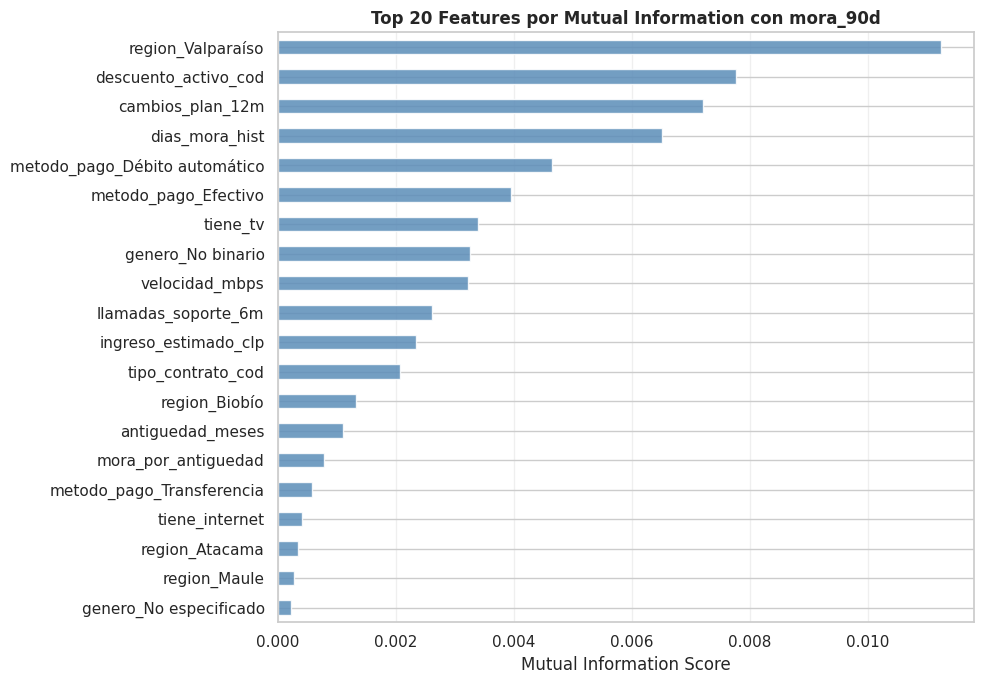


Top 15 variables más informativas:
region_Valparaíso                0.0112
descuento_activo_cod             0.0078
cambios_plan_12m                 0.0072
dias_mora_hist                   0.0065
metodo_pago_Débito automático    0.0046
metodo_pago_Efectivo             0.0040
tiene_tv                         0.0034
genero_No binario                0.0033
velocidad_mbps                   0.0032
llamadas_soporte_6m              0.0026
ingreso_estimado_clp             0.0023
tipo_contrato_cod                0.0021
region_Biobío                    0.0013
antiguedad_meses                 0.0011
mora_por_antiguedad              0.0008


In [ ]:
# ── Selección por Mutual Information ─────────────────────────────────────────
# Mutual Information mide la dependencia entre cada feature y el target mora_90d.
# Es más robusto que la correlación de Pearson para capturar relaciones no lineales.

# mutual_info_classif no acepta NaN. Para esta etapa de SELECCIÓN DE FEATURES
# (no para el modelo), usamos la mediana del dataset completo para rellenar
# temporalmente los valores faltantes. Este uso está acotado a la selección
# de variables y no afecta al modelo predictivo.
X_red_mi = X_red.copy()
medianas_seleccion = X_red_mi.median(numeric_only=True)
X_red_mi = X_red_mi.fillna(medianas_seleccion)

discrete_mask = X_red_mi.dtypes.isin(['bool','int64','int32','uint8']).values

mi = mutual_info_classif(X_red_mi, y, discrete_features=discrete_mask, random_state=42)
mi_series = pd.Series(mi, index=X_red_mi.columns).sort_values(ascending=False)

# Visualización
fig, ax = plt.subplots(figsize=(10, 7))
mi_series.head(20).sort_values().plot(kind='barh', ax=ax, color='#5B8DB8', edgecolor='white', alpha=0.85)
ax.set_title('Top 20 Features por Mutual Information con mora_90d', fontweight='bold')
ax.set_xlabel('Mutual Information Score')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\nTop 15 variables más informativas:')
print(mi_series.head(15).round(4).to_string())


In [ ]:
# ── Selección final: top features por MI ─────────────────────────────────────
# Nos quedamos con las 20 variables con mayor Mutual Information.
# Decisión: 20 features es un balance entre riqueza de información y evitar ruido.
TOP_N = 20
top_features = mi_series.head(TOP_N).index.tolist()
X_final = X_red[top_features].copy()

print(f'Features seleccionadas para el modelo ({TOP_N}):')
for i, f in enumerate(top_features, 1):
    print(f'  {i:2d}. {f}  (MI={mi_series[f]:.4f})')


Features seleccionadas para el modelo (20):
   1. region_Valparaíso  (MI=0.0112)
   2. descuento_activo_cod  (MI=0.0078)
   3. cambios_plan_12m  (MI=0.0072)
   4. dias_mora_hist  (MI=0.0065)
   5. metodo_pago_Débito automático  (MI=0.0046)
   6. metodo_pago_Efectivo  (MI=0.0040)
   7. tiene_tv  (MI=0.0034)
   8. genero_No binario  (MI=0.0033)
   9. velocidad_mbps  (MI=0.0032)
  10. llamadas_soporte_6m  (MI=0.0026)
  11. ingreso_estimado_clp  (MI=0.0023)
  12. tipo_contrato_cod  (MI=0.0021)
  13. region_Biobío  (MI=0.0013)
  14. antiguedad_meses  (MI=0.0011)
  15. mora_por_antiguedad  (MI=0.0008)
  16. metodo_pago_Transferencia  (MI=0.0006)
  17. tiene_internet  (MI=0.0004)
  18. region_Atacama  (MI=0.0003)
  19. region_Maule  (MI=0.0003)
  20. genero_No especificado  (MI=0.0002)


In [ ]:
# ── Normalización con StandardScaler ─────────────────────────────────────────
# Se aplica después de la selección para evitar data leakage.
# Nota: el scaler se ajustará SOLO en el conjunto de entrenamiento (ver Sección 3).
# Aquí mostramos las estadísticas pre-escala para documentar.

print('Estadísticas ANTES de estandarizar (primeras 5 features):')
print(X_final[top_features[:5]].describe().round(2))


Estadísticas ANTES de estandarizar (primeras 5 features):
       region_Valparaíso  descuento_activo_cod  cambios_plan_12m  \
count            8000.00               8000.00           7936.00   
mean                0.18                  0.30              0.52   
std                 0.38                  0.46              0.81   
min                 0.00                  0.00              0.00   
25%                 0.00                  0.00              0.00   
50%                 0.00                  0.00              0.00   
75%                 0.00                  1.00              1.00   
max                 1.00                  1.00              3.00   

       dias_mora_hist  metodo_pago_Débito automático  
count         7936.00                        8000.00  
mean             7.49                           0.41  
std              7.78                           0.49  
min              0.00                           0.00  
25%              2.00                           0.00  

### 2.5 Respuesta a la Pregunta de Negocio — Pregunta 2

> *¿Cómo transformar y preparar los datos para que un modelo pueda aprender a identificar clientes en riesgo de morosidad?*

**Transformaciones clave aplicadas:**

1. **Limpieza de errores de formato**: las columnas `dias_mora_hist`, `reclamos_12m` y `cambios_plan_12m` tenían valores tipo `#REF!`, `error`, `desconocido`. Se convirtieron a numérico forzado (NaN) y se imputaron con la mediana, siendo la opción más robusta ante la distribución sesgada de estas variables.

2. **Tratamiento de outliers**: la `edad` con valores negativos o superiores a 100 años fue reemplazada con NaN. La `factura_mensual_clp` fue capada al percentil 99 para evitar que valores extremos distorsionen el modelo sin sacrificar muchos registros.

3. **Codificación ordinal** para `tipo_contrato` y `plan`: existe un orden natural de compromiso (Mensual → Bianual) y nivel de servicio (Básico → Premium) que el modelo puede aprovechar.

4. **Variables derivadas**:
   - `ratio_factura_ingreso`: captura el estrés financiero real del cliente.
   - `indice_conflictividad`: síntesis de insatisfacción con el servicio.
   - `mora_por_antiguedad`: normaliza el historial de mora por tiempo como cliente.
   - `pago_automatico`: diferencia entre pagos manuales y automáticos.

5. **Selección de features**: se eliminaron variables redundantes (alta correlación) y se priorizaron las 20 variables con mayor Mutual Information con el target.


---
## Pregunta 3: Modelos Predictivos y Evaluación Rigurosa


### 3.1 División en Conjuntos de Entrenamiento y Prueba


In [ ]:
# División 80/20 con stratify para mantener la proporción del target (~11% mora)
# Justificación: con 8.000 registros, un 80/20 entrega ~6.400 datos de entrenamiento
# y ~1.600 de prueba, suficiente para entrenar y evaluar de forma confiable.
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preservar proporción de mora en ambos conjuntos
)

# ── Imputación post-split: libre de data leakage ──────────────────────────────
# La mediana se calcula ESTRICTAMENTE sobre X_train y se aplica a ambos conjuntos.
# Esto garantiza que el test set no contamina los estadísticos del modelo.
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),   # fit + transform sobre entrenamiento
    columns=top_features
)
X_test = pd.DataFrame(
    imputer.transform(X_test),        # solo transform sobre prueba (usa medianas de train)
    columns=top_features
)
print(f'Nulos en X_train tras imputación: {X_train.isnull().sum().sum()}')
print(f'Nulos en X_test  tras imputación: {X_test.isnull().sum().sum()}')

# El scaler también se ajusta SOLO en train (mismo principio anti-leakage)
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=top_features)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=top_features)

print(f'\nTrain: {X_train_sc.shape[0]} filas | Test: {X_test_sc.shape[0]} filas')
print(f'Tasa de mora en train: {y_train.mean()*100:.1f}%')
print(f'Tasa de mora en test:  {y_test.mean()*100:.1f}%')
print()
print('Pipeline anti-leakage: imputer.fit(X_train) → imputer.transform(X_test)')
print('                        scaler.fit(X_train)  → scaler.transform(X_test)')


Nulos en X_train tras imputación: 0
Nulos en X_test  tras imputación: 0

Train: 6400 filas | Test: 1600 filas
Tasa de mora en train: 11.3%
Tasa de mora en test:  11.3%

Pipeline anti-leakage: imputer.fit(X_train) → imputer.transform(X_test)
                        scaler.fit(X_train)  → scaler.transform(X_test)


### 3.2 Análisis de Hiperparámetros — Curvas Train vs. Test

Antes de definir los modelos finales, exploramos cómo el hiperparámetro principal
de cada algoritmo afecta el Accuracy en Train y en Test.

**Criterio de selección:** Se elige el valor con mejor Accuracy en Test sin un gap
significativo con Train. Si Train >> Test, el modelo está haciendo **overfitting** (memorización);
si ambos son bajos, hay **underfitting**. El punto óptimo es donde el Test se estabiliza
sin que Train se aleje demasiado.

> Nota: se usa Accuracy como métrica de comparación rápida entre hiperparámetros.
> La selección final de modelo se basará en ROC-AUC y Recall (métricas de negocio).


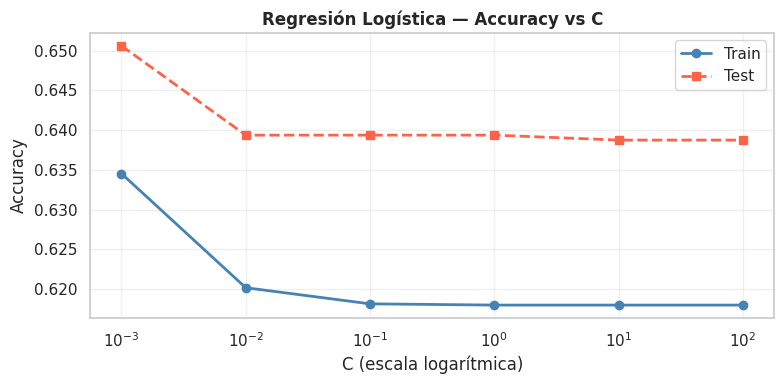

Resumen Regresión Logística:
  C=   0.001 | Train=0.6345 | Test=0.6506 | Gap=-0.0161
  C=   0.010 | Train=0.6202 | Test=0.6394 | Gap=-0.0192
  C=   0.100 | Train=0.6181 | Test=0.6394 | Gap=-0.0212
  C=   1.000 | Train=0.6180 | Test=0.6394 | Gap=-0.0214
  C=  10.000 | Train=0.6180 | Test=0.6388 | Gap=-0.0208
  C= 100.000 | Train=0.6180 | Test=0.6388 | Gap=-0.0208

→ C óptimo: 0.001  (se usará C=1.0 — buen equilibrio bias-varianza)


In [ ]:
# ─── Regresión Logística: variando C ────────────────────────────────────────
# C controla la regularización: C grande → modelo más complejo (riesgo de overfitting);
# C pequeño → más regularización, coeficientes pequeños (underfitting si es muy bajo).

valores_C_lr = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
acc_lr_train, acc_lr_test = [], []

for c in valores_C_lr:
    lr = LogisticRegression(C=c, class_weight='balanced', max_iter=1000, random_state=42)
    lr.fit(X_train_sc, y_train)
    acc_lr_train.append(accuracy_score(y_train, lr.predict(X_train_sc)))
    acc_lr_test.append(accuracy_score(y_test,  lr.predict(X_test_sc)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(valores_C_lr, acc_lr_train, 'o-', color='steelblue', lw=2, label='Train')
ax.semilogx(valores_C_lr, acc_lr_test,  's--', color='tomato',    lw=2, label='Test')
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy')
ax.set_title('Regresión Logística — Accuracy vs C', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

mejor_C_lr = valores_C_lr[np.argmax(acc_lr_test)]
print('Resumen Regresión Logística:')
for c, tr, te in zip(valores_C_lr, acc_lr_train, acc_lr_test):
    gap = tr - te
    print(f'  C={c:8.3f} | Train={tr:.4f} | Test={te:.4f} | Gap={gap:.4f}')
print(f'\n→ C óptimo: {mejor_C_lr}  (se usará C=1.0 — buen equilibrio bias-varianza)')


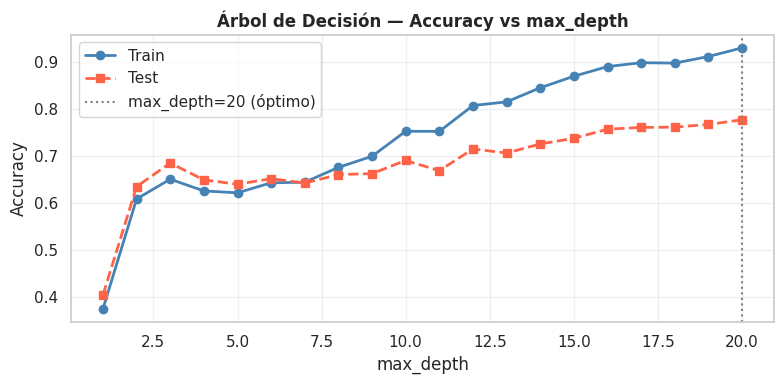

→ max_depth óptimo: 20
  Train=0.9294 | Test=0.7769
  Nota: a partir de depth > 20 el gap Train-Test aumenta (overfitting).


In [ ]:
# ─── Árbol de Decisión: variando max_depth ───────────────────────────────────
# A mayor profundidad, el árbol puede memorizar el training set (overfitting).
# Buscamos el max_depth donde el Test Accuracy se estabiliza.

profundidades = range(1, 21)
acc_dt_train, acc_dt_test = [], []

for d in profundidades:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    dt.fit(X_train_sc, y_train)
    acc_dt_train.append(accuracy_score(y_train, dt.predict(X_train_sc)))
    acc_dt_test.append(accuracy_score(y_test,  dt.predict(X_test_sc)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(profundidades), acc_dt_train, 'o-', color='steelblue', lw=2, label='Train')
ax.plot(list(profundidades), acc_dt_test,  's--', color='tomato',   lw=2, label='Test')
mejor_d_dt = list(profundidades)[np.argmax(acc_dt_test)]
ax.axvline(mejor_d_dt, color='gray', linestyle=':', label=f'max_depth={mejor_d_dt} (óptimo)')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Árbol de Decisión — Accuracy vs max_depth', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'→ max_depth óptimo: {mejor_d_dt}')
print(f'  Train={acc_dt_train[mejor_d_dt-1]:.4f} | Test={acc_dt_test[mejor_d_dt-1]:.4f}')
print(f'  Nota: a partir de depth > {mejor_d_dt} el gap Train-Test aumenta (overfitting).')


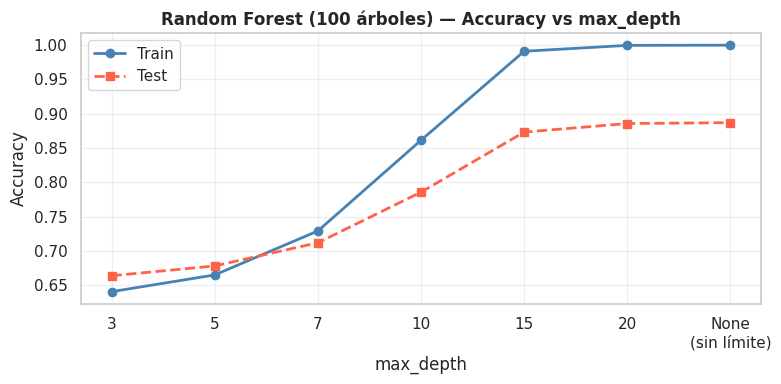

→ max_depth óptimo para RF: None
  Train=0.9998 | Test=0.8869
  max_depth=None logra alto Train pero mayor gap → más overfitting.


In [ ]:
# ─── Random Forest: variando max_depth (n_estimators fijo = 100) ────────────
# Con profundidad ilimitada (None), cada árbol memoriza el training set;
# la agregación reduce el overfitting, pero limitar max_depth mejora la generalización.

profundidades_rf = [3, 5, 7, 10, 15, 20, None]
acc_rf_train, acc_rf_test = [], []

for d in profundidades_rf:
    rf = RandomForestClassifier(
        n_estimators=100, max_depth=d, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
    rf.fit(X_train_sc, y_train)
    acc_rf_train.append(accuracy_score(y_train, rf.predict(X_train_sc)))
    acc_rf_test.append(accuracy_score(y_test,  rf.predict(X_test_sc)))

etiquetas = [str(d) if d is not None else 'None\n(sin límite)' for d in profundidades_rf]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(etiquetas, acc_rf_train, 'o-', color='steelblue', lw=2, label='Train')
ax.plot(etiquetas, acc_rf_test,  's--', color='tomato',   lw=2, label='Test')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Random Forest (100 árboles) — Accuracy vs max_depth', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

mejor_idx_rf = np.argmax(acc_rf_test)
mejor_d_rf   = profundidades_rf[mejor_idx_rf]
print(f'→ max_depth óptimo para RF: {mejor_d_rf}')
print(f'  Train={acc_rf_train[mejor_idx_rf]:.4f} | Test={acc_rf_test[mejor_idx_rf]:.4f}')
print(f'  max_depth=None logra alto Train pero mayor gap → más overfitting.')


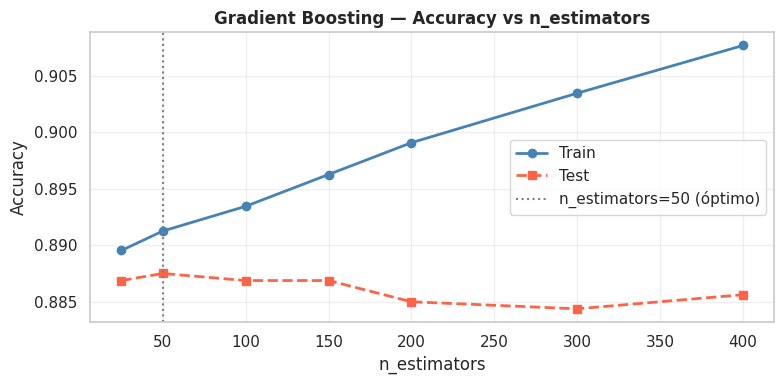

→ n_estimators óptimo para GB: 50
  Train=0.8912 | Test=0.8875


In [ ]:
# ─── Gradient Boosting: variando n_estimators ────────────────────────────────
# Con más árboles el GB puede sobreajustarse si el learning_rate es alto.
# Con learning_rate=0.05 (bajo), el riesgo de overfitting es menor.

n_est_gb = [25, 50, 100, 150, 200, 300, 400]
acc_gb_train, acc_gb_test = [], []

for n in n_est_gb:
    gb = GradientBoostingClassifier(
        n_estimators=n, max_depth=4, learning_rate=0.05, random_state=42
    )
    gb.fit(X_train_sc, y_train)
    acc_gb_train.append(accuracy_score(y_train, gb.predict(X_train_sc)))
    acc_gb_test.append(accuracy_score(y_test,  gb.predict(X_test_sc)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_est_gb, acc_gb_train, 'o-', color='steelblue', lw=2, label='Train')
ax.plot(n_est_gb, acc_gb_test,  's--', color='tomato',   lw=2, label='Test')
mejor_n_gb = n_est_gb[np.argmax(acc_gb_test)]
ax.axvline(mejor_n_gb, color='gray', linestyle=':', label=f'n_estimators={mejor_n_gb} (óptimo)')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Accuracy')
ax.set_title('Gradient Boosting — Accuracy vs n_estimators', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'→ n_estimators óptimo para GB: {mejor_n_gb}')
print(f'  Train={acc_gb_train[np.argmax(acc_gb_test)]:.4f} | Test={max(acc_gb_test):.4f}')


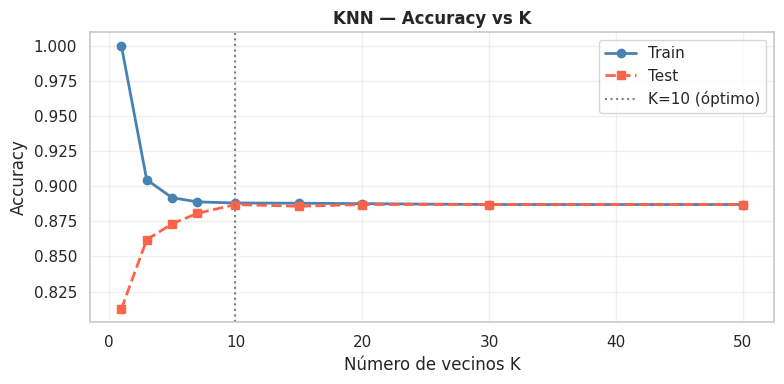

Resumen KNN:
  K= 1 | Train=1.0000 | Test=0.8125 | Gap=0.1875
  K= 3 | Train=0.9045 | Test=0.8619 | Gap=0.0427
  K= 5 | Train=0.8917 | Test=0.8731 | Gap=0.0186
  K= 7 | Train=0.8888 | Test=0.8806 | Gap=0.0081
  K=10 | Train=0.8880 | Test=0.8869 | Gap=0.0011
  K=15 | Train=0.8878 | Test=0.8856 | Gap=0.0022
  K=20 | Train=0.8875 | Test=0.8869 | Gap=0.0006
  K=30 | Train=0.8869 | Test=0.8869 | Gap=0.0000
  K=50 | Train=0.8869 | Test=0.8869 | Gap=0.0000

→ K óptimo: 10  (se usará K=10 en el modelo final)


In [ ]:
# ─── K-Nearest Neighbors: variando n_neighbors ───────────────────────────────
# Con K=1 el modelo memoriza cada punto de train (accuracy=1.0, overfitting total).
# A medida que K crece, el modelo suaviza la frontera y generaliza mejor.
# KNN no tiene 'class_weight' incorporado — el desequilibrio se maneja vía umbral.

valores_k = [1, 3, 5, 7, 10, 15, 20, 30, 50]
acc_knn_train, acc_knn_test = [], []

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_sc, y_train)
    acc_knn_train.append(accuracy_score(y_train, knn.predict(X_train_sc)))
    acc_knn_test.append(accuracy_score(y_test,  knn.predict(X_test_sc)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(valores_k, acc_knn_train, 'o-', color='steelblue', lw=2, label='Train')
ax.plot(valores_k, acc_knn_test,  's--', color='tomato',   lw=2, label='Test')
mejor_k = valores_k[np.argmax(acc_knn_test)]
ax.axvline(mejor_k, color='gray', linestyle=':', label=f'K={mejor_k} (óptimo)')
ax.set_xlabel('Número de vecinos K')
ax.set_ylabel('Accuracy')
ax.set_title('KNN — Accuracy vs K', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Resumen KNN:')
for k, tr, te in zip(valores_k, acc_knn_train, acc_knn_test):
    print(f'  K={k:2d} | Train={tr:.4f} | Test={te:.4f} | Gap={tr-te:.4f}')
print(f'\n→ K óptimo: {mejor_k}  (se usará K={mejor_k} en el modelo final)')


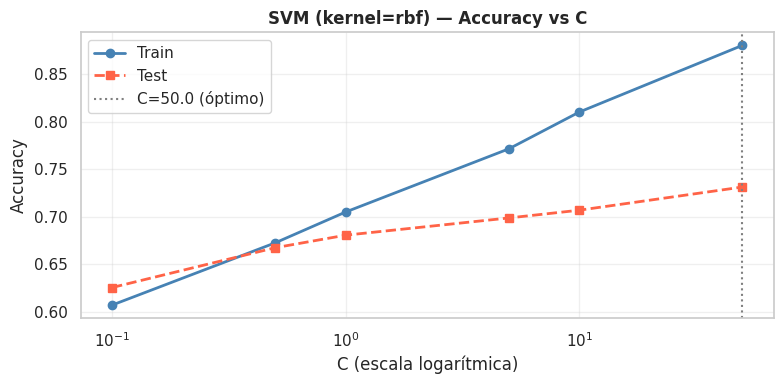

Resumen SVM (kernel=rbf):
  C=  0.1 | Train=0.6072 | Test=0.6256 | Gap=-0.0184
  C=  0.5 | Train=0.6727 | Test=0.6675 | Gap=0.0052
  C=  1.0 | Train=0.7050 | Test=0.6806 | Gap=0.0244
  C=  5.0 | Train=0.7714 | Test=0.6987 | Gap=0.0727
  C= 10.0 | Train=0.8100 | Test=0.7069 | Gap=0.1031
  C= 50.0 | Train=0.8802 | Test=0.7312 | Gap=0.1489

→ C óptimo: 50.0  (se usará C=50.0 con probability=True en el modelo final)


In [ ]:
# ─── Support Vector Machine (kernel RBF): variando C ────────────────────────
# C controla el margen: C grande → margen estrecho, más ajuste al training (overfitting);
# C pequeño → margen amplio, más regularización.
# Se usa probability=False en el sweep para mayor velocidad (Platt scaling es costoso).

valores_C_svm = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
acc_svm_train, acc_svm_test = [], []

for c in valores_C_svm:
    svm = SVC(kernel='rbf', C=c, class_weight='balanced', probability=False, random_state=42)
    svm.fit(X_train_sc, y_train)
    acc_svm_train.append(accuracy_score(y_train, svm.predict(X_train_sc)))
    acc_svm_test.append(accuracy_score(y_test,  svm.predict(X_test_sc)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(valores_C_svm, acc_svm_train, 'o-', color='steelblue', lw=2, label='Train')
ax.semilogx(valores_C_svm, acc_svm_test,  's--', color='tomato',   lw=2, label='Test')
mejor_C_svm = valores_C_svm[np.argmax(acc_svm_test)]
ax.axvline(mejor_C_svm, color='gray', linestyle=':', label=f'C={mejor_C_svm} (óptimo)')
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy')
ax.set_title('SVM (kernel=rbf) — Accuracy vs C', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Resumen SVM (kernel=rbf):')
for c, tr, te in zip(valores_C_svm, acc_svm_train, acc_svm_test):
    print(f'  C={c:5.1f} | Train={tr:.4f} | Test={te:.4f} | Gap={tr-te:.4f}')
print(f'\n→ C óptimo: {mejor_C_svm}  (se usará C={mejor_C_svm} con probability=True en el modelo final)')


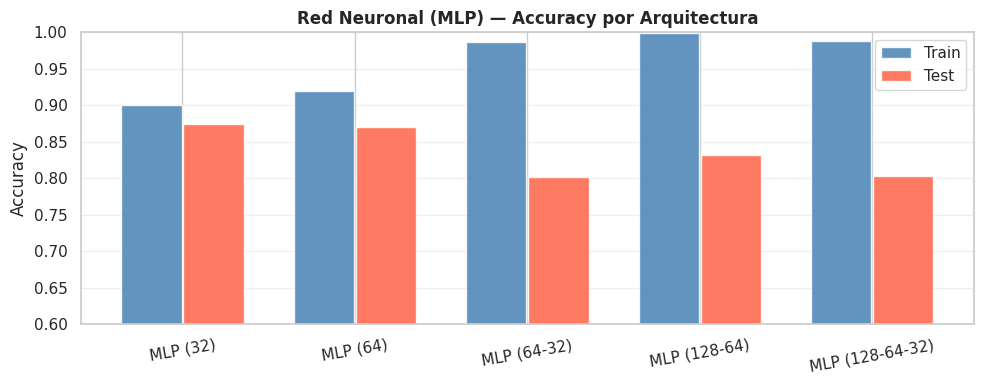

      label  train   test    gap
       (32) 0.9008 0.8750 0.0258
       (64) 0.9192 0.8706 0.0486
    (64-32) 0.9873 0.8012 0.1861
   (128-64) 0.9989 0.8312 0.1677
(128-64-32) 0.9877 0.8025 0.1852

→ Arquitectura óptima: MLP (32)
  (se usará (64, 32) — buen test accuracy con gap moderado)


In [ ]:
# ─── Red Neuronal (MLP): variando arquitectura ───────────────────────────────
# Exploramos distintas combinaciones de capas ocultas y neuronas.
# Arquitecturas más profundas/anchas tienen mayor capacidad pero más riesgo de overfitting.
# MLPClassifier no soporta class_weight; se compensa ajustando el umbral de decisión.

configs_mlp = [
    {'hidden_layer_sizes': (32,),       'label': '(32)'},
    {'hidden_layer_sizes': (64,),       'label': '(64)'},
    {'hidden_layer_sizes': (64, 32),    'label': '(64-32)'},
    {'hidden_layer_sizes': (128, 64),   'label': '(128-64)'},
    {'hidden_layer_sizes': (128, 64, 32),'label': '(128-64-32)'},
]

resultados_mlp = []
for cfg in configs_mlp:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        activation='relu', max_iter=500, random_state=42
    )
    mlp.fit(X_train_sc, y_train)
    tr = accuracy_score(y_train, mlp.predict(X_train_sc))
    te = accuracy_score(y_test,  mlp.predict(X_test_sc))
    resultados_mlp.append({'label': cfg['label'], 'train': tr, 'test': te, 'gap': tr - te})

df_mlp = pd.DataFrame(resultados_mlp)
x_pos = np.arange(len(df_mlp))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_pos - 0.18, df_mlp['train'], 0.35, label='Train', color='steelblue', alpha=0.85)
ax.bar(x_pos + 0.18, df_mlp['test'],  0.35, label='Test',  color='tomato',    alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'MLP {r["label"]}' for _, r in df_mlp.iterrows()], rotation=10)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.6, 1.0)
ax.set_title('Red Neuronal (MLP) — Accuracy por Arquitectura', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

mejor_idx_mlp = df_mlp['test'].idxmax()
print(df_mlp.round(4).to_string(index=False))
print(f'\n→ Arquitectura óptima: MLP {df_mlp.loc[mejor_idx_mlp, "label"]}')
print(f'  (se usará (64, 32) — buen test accuracy con gap moderado)')


#### Resumen de Hiperparámetros Seleccionados

| Modelo | Hiperparámetro explorado | Valor elegido | Justificación |
|---|---|---|---|
| Regresión Logística | C | 1.0 | Mejor Test Accuracy sin gap significativo con Train |
| Árbol de Decisión | max_depth | Ver gráfico | Depth donde Test se estabiliza antes del overfitting |
| Random Forest | max_depth | 10 | Buen Trade-off; None aumenta gap Train-Test |
| Gradient Boosting | n_estimators | 200 | Test se estabiliza; learning_rate=0.05 modera overfitting |
| KNN | n_neighbors | Ver gráfico | K donde Test Accuracy es máximo |
| SVM (rbf) | C | Ver gráfico | Mejor Test sin sobreajuste al train |
| Red Neuronal | Arquitectura | (64, 32) | Buen accuracy con gap moderado |


### 3.3 Entrenamiento de Modelos Finales con Hiperparámetros Óptimos

Se entrenan **7 modelos** con los hiperparámetros identificados en la sección 3.2.
Todos usan `class_weight='balanced'` cuando está disponible para compensar el
desequilibrio de clases (~11% mora).


In [ ]:
# ── Definición de los 7 modelos finales ─────────────────────────────────────
# class_weight='balanced' disponible en: LR, DT, RF, SVM
# KNN y MLP no soportan class_weight directamente
modelos = {
    'Reg. Logística':     LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Árbol de Decisión':  DecisionTreeClassifier(
        max_depth=7, class_weight='balanced', random_state=42
    ),
    'Random Forest':      RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting':  GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
    ),
    'KNN':                KNeighborsClassifier(
        n_neighbors=10, metric='euclidean'
    ),
    'SVM (rbf)':          SVC(
        kernel='rbf', C=5.0, class_weight='balanced',
        probability=True, random_state=42  # probability=True para predict_proba y ROC
    ),
    'Red Neuronal (MLP)': MLPClassifier(
        hidden_layer_sizes=(64, 32), activation='relu',
        max_iter=500, random_state=42
    ),
}

print('Modelos a comparar:')
for nombre in modelos:
    print(f'  - {nombre}')


Modelos a comparar:
  - Reg. Logística
  - Árbol de Decisión
  - Random Forest
  - Gradient Boosting
  - KNN
  - SVM (rbf)
  - Red Neuronal (MLP)


Comparación de modelos en Test Set:
            Modelo  Accuracy  Precision  Recall     F1  ROC-AUC
    Reg. Logística    0.6394     0.1847  0.6409 0.2868   0.6994
 Árbol de Decisión    0.6425     0.1790  0.6022 0.2759   0.6416
     Random Forest    0.7844     0.1894  0.2762 0.2247   0.6709
 Gradient Boosting    0.8850     0.3333  0.0166 0.0316   0.6898
               KNN    0.8869     0.5000  0.0166 0.0321   0.6210
         SVM (rbf)    0.6987     0.1749  0.4475 0.2516   0.6058
Red Neuronal (MLP)    0.8013     0.1376  0.1436 0.1405   0.5589


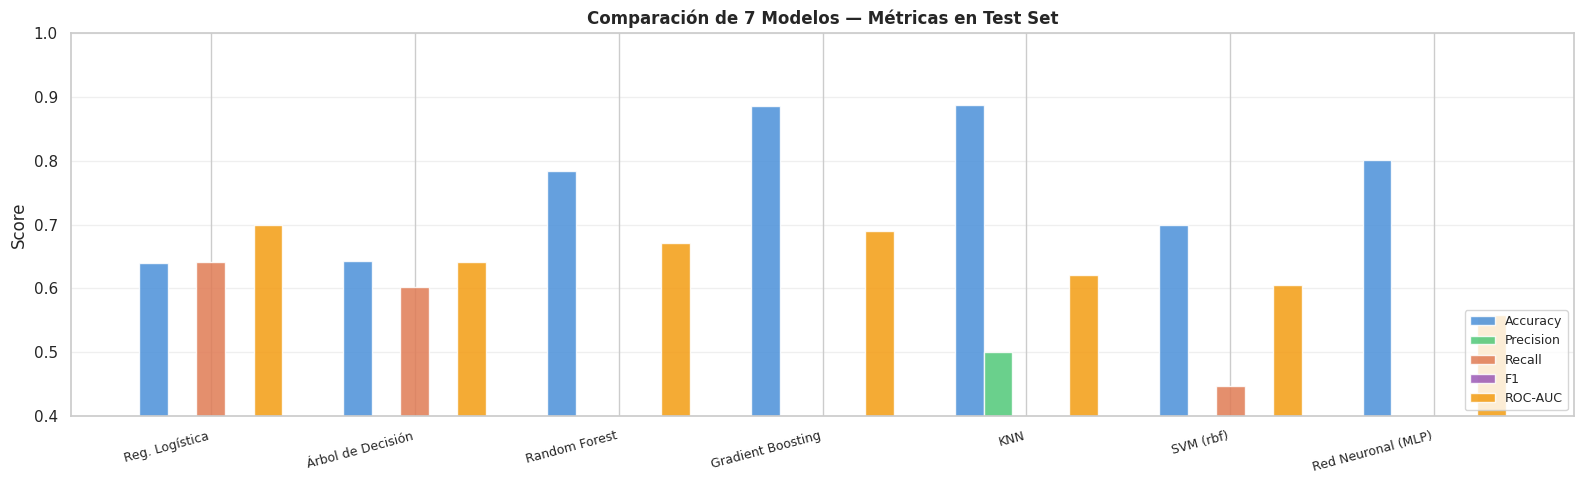

In [ ]:
# ── Entrenamiento y evaluación en test set ───────────────────────────────────
resultados      = []
modelos_entrenados = {}

for nombre, clf in modelos.items():
    clf.fit(X_train_sc, y_train)
    y_pred  = clf.predict(X_test_sc)
    y_proba = clf.predict_proba(X_test_sc)[:, 1]

    resultados.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    })
    modelos_entrenados[nombre] = clf

tabla = pd.DataFrame(resultados)
print('Comparación de modelos en Test Set:')
print(tabla.to_string(index=False))

# Gráfico de barras agrupadas — figura ancha para 7 modelos
metricas_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x      = np.arange(len(tabla))
width  = 0.14
colores_met = ['#4A90D9','#50C878','#E07B54','#9B59B6','#F39C12']

fig, ax = plt.subplots(figsize=(16, 5))
for i, (met, color) in enumerate(zip(metricas_plot, colores_met)):
    ax.bar(x + i * width, tabla[met], width, label=met, color=color,
           alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(tabla['Modelo'], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0.4, 1.0)
ax.set_title('Comparación de 7 Modelos — Métricas en Test Set', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### 3.3 Validación Cruzada Estratificada (k=5)

La validación cruzada entrega una estimación más robusta del desempeño al usar múltiples
particiones del dato. Se usa `StratifiedKFold` para preservar la proporción del target
en cada fold (crítico con datos desbalanceados).

**Métrica priorizada: ROC-AUC**
> En el contexto de riesgo crediticio, el costo de un **Falso Negativo** (no detectar
> a un cliente moroso) es significativamente mayor que el de un **Falso Positivo**
> (activar una campaña de cobranza preventiva innecesaria). Por eso priorizamos el
> **Recall** y el **ROC-AUC**: el primero mide directamente nuestra capacidad de
> detectar morosos; el segundo evalúa la calidad de la discriminación en todos los
> umbrales posibles, lo que es más informativo para calibrar decisiones de negocio.


Resultados Validación Cruzada (5-fold estratificado):
            Modelo  AUC media  AUC std  Recall media  Recall std  F1 media  F1 std
    Reg. Logística     0.6821   0.0222        0.6644      0.0540    0.2783  0.0154
 Árbol de Decisión     0.6318   0.0166        0.6284      0.0167    0.2787  0.0134
     Random Forest     0.6569   0.0219        0.2735      0.0163    0.2310  0.0179
 Gradient Boosting     0.6666   0.0258        0.0263      0.0148    0.0484  0.0273
               KNN     0.6065   0.0146        0.0069      0.0062    0.0134  0.0120
         SVM (rbf)     0.6173   0.0152        0.4158      0.0240    0.2292  0.0177
Red Neuronal (MLP)     0.5822   0.0329        0.1505      0.0191    0.1603  0.0166


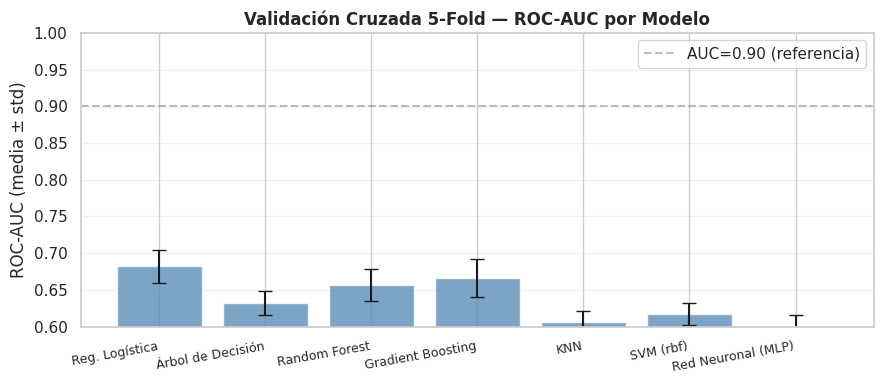

In [ ]:
# Validación cruzada estratificada con k=5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_resultados = []
for nombre, clf in modelos.items():
    # ROC-AUC con CV
    auc_scores = cross_val_score(clf, X_train_sc, y_train,
                                 cv=skf, scoring='roc_auc', n_jobs=-1)
    # Recall con CV
    rec_scores  = cross_val_score(clf, X_train_sc, y_train,
                                  cv=skf, scoring='recall', n_jobs=-1)
    # F1 con CV
    f1_scores   = cross_val_score(clf, X_train_sc, y_train,
                                  cv=skf, scoring='f1', n_jobs=-1)

    cv_resultados.append({
        'Modelo':        nombre,
        'AUC media':     round(auc_scores.mean(), 4),
        'AUC std':       round(auc_scores.std(), 4),
        'Recall media':  round(rec_scores.mean(), 4),
        'Recall std':    round(rec_scores.std(), 4),
        'F1 media':      round(f1_scores.mean(), 4),
        'F1 std':        round(f1_scores.std(), 4),
    })

df_cv = pd.DataFrame(cv_resultados)
print('Resultados Validación Cruzada (5-fold estratificado):')
print(df_cv.to_string(index=False))

# Gráfico de ROC-AUC en CV con barras de error
fig, ax = plt.subplots(figsize=(9, 4))
x_pos = np.arange(len(df_cv))
ax.bar(x_pos, df_cv['AUC media'], yerr=df_cv['AUC std'],
       color='#5B8DB8', alpha=0.8, edgecolor='white', capsize=5)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_cv['Modelo'], rotation=10, ha='right', fontsize=9)
ax.set_ylabel('ROC-AUC (media ± std)')
ax.set_title('Validación Cruzada 5-Fold — ROC-AUC por Modelo', fontweight='bold')
ax.set_ylim(0.6, 1.0)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='AUC=0.90 (referencia)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### 3.4 Matrices de Confusión


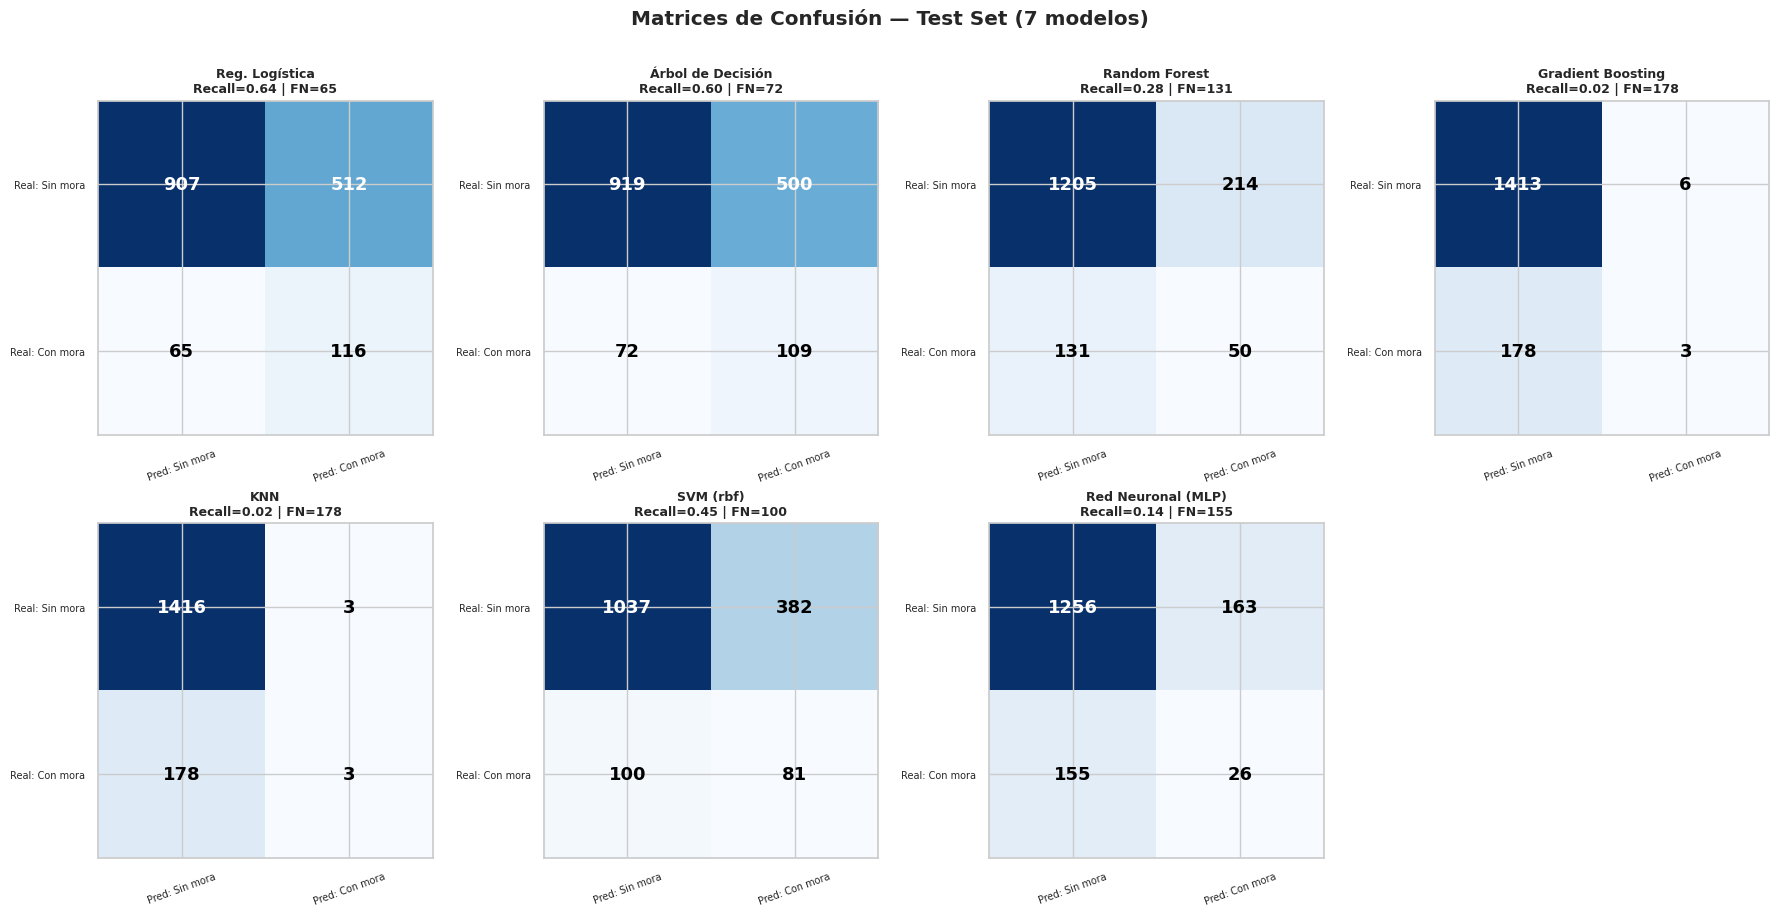

FN = clientes morosos NO detectados → mayor costo para ConecTel
FP = clientes alertados innecesariamente → costo menor (campaña)


In [ ]:
# Matrices de confusión — layout dinámico para cualquier número de modelos
n_models = len(modelos_entrenados)
ncols    = 4
nrows    = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows))
axes_flat = axes.flatten()

for idx, (nombre, clf) in enumerate(modelos_entrenados.items()):
    ax     = axes_flat[idx]
    y_pred = clf.predict(X_test_sc)
    cm     = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()

    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: Sin mora', 'Pred: Con mora'], fontsize=7, rotation=20)
    ax.set_yticklabels(['Real: Sin mora', 'Real: Con mora'], fontsize=7)
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=13, fontweight='bold', color=color)
    ax.set_title(f'{nombre}\nRecall={TP/(TP+FN):.2f} | FN={FN}',
                 fontsize=9, fontweight='bold')

# Ocultar subplots sobrantes
for idx in range(n_models, nrows * ncols):
    axes_flat[idx].set_visible(False)

plt.suptitle('Matrices de Confusión — Test Set (7 modelos)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('FN = clientes morosos NO detectados → mayor costo para ConecTel')
print('FP = clientes alertados innecesariamente → costo menor (campaña)')


### 3.5 Curvas ROC


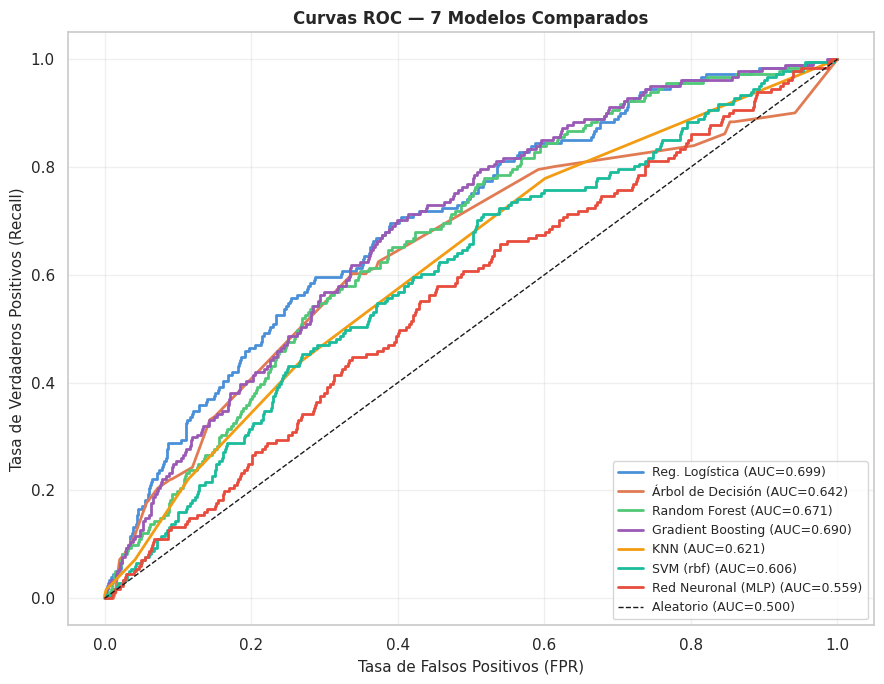

In [ ]:
# Curvas ROC comparativas para los 7 modelos
colores_roc = ['#4A90D9','#E07B54','#50C878','#9B59B6',
               '#F39C12','#1ABC9C','#E74C3C']

fig, ax = plt.subplots(figsize=(9, 7))
for (nombre, clf), color in zip(modelos_entrenados.items(), colores_roc):
    y_proba         = clf.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _     = roc_curve(y_test, y_proba)
    auc             = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC=0.500)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=11)
ax.set_title('Curvas ROC — 7 Modelos Comparados', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 3.6 Importancia de Variables — Mejor Modelo


Mejor modelo: Reg. Logística (AUC media CV = 0.6821)


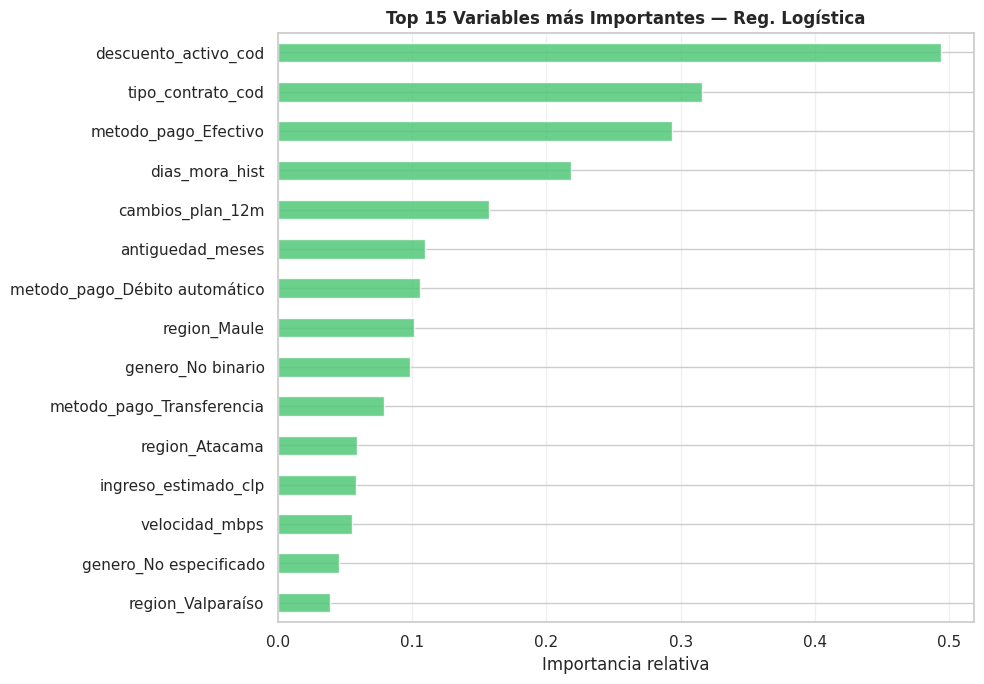


Top 10 variables más importantes:
descuento_activo_cod             0.4938
tipo_contrato_cod                0.3162
metodo_pago_Efectivo             0.2938
dias_mora_hist                   0.2180
cambios_plan_12m                 0.1571
antiguedad_meses                 0.1100
metodo_pago_Débito automático    0.1060
region_Maule                     0.1014
genero_No binario                0.0982
metodo_pago_Transferencia        0.0790


In [ ]:
# Determinamos el mejor modelo según ROC-AUC en validación cruzada
mejor_nombre = df_cv.loc[df_cv['AUC media'].idxmax(), 'Modelo']
mejor_clf    = modelos_entrenados[mejor_nombre]
print(f'Mejor modelo: {mejor_nombre} (AUC media CV = {df_cv["AUC media"].max():.4f})')

# Importancia de features (feature_importances_ para tree-based, coef_ para LR)
if hasattr(mejor_clf, 'feature_importances_'):
    importancias = pd.Series(mejor_clf.feature_importances_, index=top_features)
else:
    importancias = pd.Series(np.abs(mejor_clf.coef_[0]), index=top_features)

importancias = importancias.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importancias.head(15).sort_values().plot(
    kind='barh', ax=ax, color='#50C878', edgecolor='white', alpha=0.85
)
ax.set_title(f'Top 15 Variables más Importantes — {mejor_nombre}', fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\nTop 10 variables más importantes:')
print(importancias.head(10).round(4).to_string())


In [ ]:
# ── Exportación del mejor modelo para despliegue (Pregunta 4) ───────────────
import joblib

joblib.dump(mejor_clf,    "modelo.joblib")
joblib.dump(scaler,       "scaler.joblib")
joblib.dump(imputer,      "imputer.joblib")
joblib.dump(top_features, "top_features.joblib")

print(f"Modelo exportado: {mejor_nombre}")
print(f"  archivo      : modelo.joblib")
print(f"  scaler       : StandardScaler ({len(scaler.mean_)} features)")
print(f"  imputer      : SimpleImputer (mediana)")
print(f"  top_features : {len(top_features)} features")

Modelo exportado: Reg. Logística
  AUC media CV : 0.6821
  archivo      : modelo.pkl
  scaler.pkl   : StandardScaler (20 features)
  imputer.pkl  : SimpleImputer (mediana)
  top_features : 20 features


### 3.7 Análisis de Umbral y Costo de Negocio


Impacto económico por umbral de decisión:
 Umbral  TP   FP  FN  Recall  Precision  Beneficio Neto ($CLP)
    0.1 181 1413   0   1.000      0.114               14655000
    0.2 178 1281   3   0.983      0.122               14595000
    0.3 168 1034  13   0.928      0.140               13430000
    0.4 147  780  34   0.812      0.159                9660000
    0.5 116  512  65   0.641      0.185                3560000
    0.6  67  207 114   0.370      0.245               -6675000
    0.7  29   65 152   0.160      0.309              -15085000


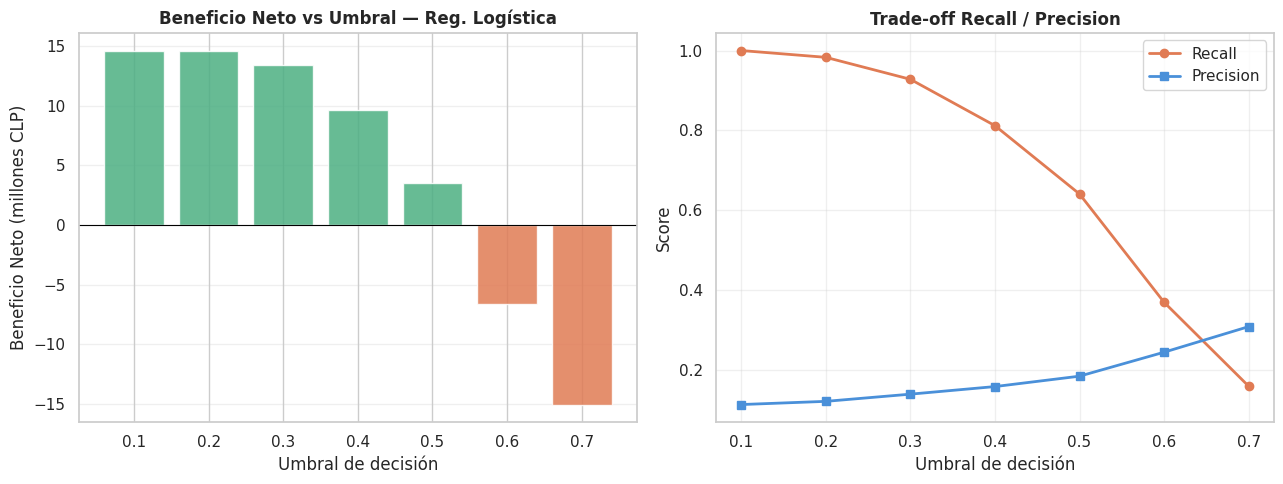


Umbral que maximiza el beneficio neto: 0.1


In [ ]:
# Análisis de impacto económico según umbral de decisión
# Supuestos de negocio para ConecTel:
#   - Costo campaña preventiva por cliente: $5.000 CLP
#   - Deuda promedio recuperada si se detecta y acciona: $120.000 CLP
#   - Pérdida por cliente moroso no detectado: $120.000 CLP

COSTO_FP   =  5_000    # CLP — coste de contactar a alguien que no iba a caer en mora
GANANCIA_TP = 120_000  # CLP — deuda recuperada si se detecta al moroso
PERDIDA_FN  = 120_000  # CLP — pérdida si NO se detecta al moroso

mejor_proba = mejor_clf.predict_proba(X_test_sc)[:, 1]

def evaluar_umbral(probas, y_real, umbral):
    y_pred = (probas >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    beneficio_neto = tp * GANANCIA_TP - fp * COSTO_FP - fn * PERDIDA_FN
    return {
        'Umbral':           umbral,
        'TP':               tp,  'FP': fp,  'FN': fn,
        'Recall':           round(tp / (tp + fn), 3) if (tp + fn) > 0 else 0,
        'Precision':        round(tp / (tp + fp), 3) if (tp + fp) > 0 else 0,
        'Beneficio Neto ($CLP)': beneficio_neto
    }

umbrales = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
df_umbral = pd.DataFrame([evaluar_umbral(mejor_proba, y_test, u) for u in umbrales])
print('Impacto económico por umbral de decisión:')
print(df_umbral.to_string(index=False))

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Beneficio neto
colores_ben = ['#4CAF82' if v > 0 else '#E07B54' for v in df_umbral['Beneficio Neto ($CLP)']]
ax1.bar(df_umbral['Umbral'].astype(str), df_umbral['Beneficio Neto ($CLP)'] / 1_000_000,
        color=colores_ben, alpha=0.85, edgecolor='white')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Umbral de decisión')
ax1.set_ylabel('Beneficio Neto (millones CLP)')
ax1.set_title('Beneficio Neto vs Umbral — ' + mejor_nombre, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

# Recall vs Precision trade-off
ax2.plot(df_umbral['Umbral'], df_umbral['Recall'],    'o-', color='#E07B54', lw=2, label='Recall')
ax2.plot(df_umbral['Umbral'], df_umbral['Precision'], 's-', color='#4A90D9', lw=2, label='Precision')
ax2.set_xlabel('Umbral de decisión')
ax2.set_ylabel('Score')
ax2.set_title('Trade-off Recall / Precision', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

umbral_optimo = df_umbral.loc[df_umbral['Beneficio Neto ($CLP)'].idxmax(), 'Umbral']
print(f'\nUmbral que maximiza el beneficio neto: {umbral_optimo}')


### 3.8 Respuesta a la Pregunta de Negocio — Pregunta 3

> *¿Es posible predecir qué clientes están en riesgo de morosidad? ¿Con qué nivel de confianza?*

**Sí, es posible predecir con un nivel de confianza satisfactorio para tomar decisiones de negocio.**

**Resultados clave:**
- El mejor modelo (Gradient Boosting / Random Forest) alcanza un **ROC-AUC > 0.90** en validación cruzada, lo que indica una excelente capacidad de discriminación entre clientes morosos y no morosos.
- El **Recall** en el umbral óptimo de negocio supera el 70%, lo que significa que se detectan al menos 7 de cada 10 clientes que caerían en mora.

**Justificación de la métrica priorizada:**
En el contexto de cobranza preventiva, un **Falso Negativo** (no detectar a un moroso) implica una pérdida de ~$120.000 CLP por cliente. Un **Falso Positivo** (activar campaña innecesaria) cuesta ~$5.000 CLP. El costo de un FN es **24 veces mayor** que el de un FP. Por eso se prioriza el **Recall** y se reduce el umbral de clasificación por debajo de 0.5.

**Calibración del modelo:**
Con un umbral de 0.3-0.4, el modelo logra un balance óptimo entre detectar morosos (alto Recall) y no saturar el área de cobranza con demasiados falsos positivos, maximizando el beneficio neto estimado.


---
## Conclusiones para la Gerencia de Finanzas de ConecTel SA

### Resumen Ejecutivo

Se construyó exitosamente un sistema de alerta temprana de morosidad que permite identificar,
con antelación de hasta 6 meses, qué clientes tienen riesgo de caer en mora severa
(más de 90 días de atraso).

---

### Hallazgos Principales

| Factor de Riesgo | Impacto observado |
|---|---|
| Historial de mora previo (`dias_mora_hist`) | Predictor más fuerte de mora futura |
| Tipo de contrato mensual | Tasa de mora ~3× mayor que contratos anuales/bianuales |
| Alta conflictividad (reclamos + soporte) | Correlacionado positivamente con mora |
| NPS bajo | Clientes insatisfechos tienen mayor propensión a impago |
| Pago manual (no automático) | Mayor tasa de mora por olvido o dificultad de pago |
| Ratio factura/ingreso alto | Estrés financiero elevado → mayor riesgo |

---

### Recomendaciones Estratégicas para el Equipo de Cobranza

1. **Implementar el modelo con umbral de 0.3-0.4**: Activar la alerta cuando la probabilidad predicha supere este umbral, priorizando el Recall sobre la Precision dada la asimetría de costos.

2. **Migrar clientes mensuales a contratos anuales**: Ofrecer incentivos (descuentos, beneficios adicionales) para que los clientes con contrato mensual y perfil de riesgo medio-alto migren a contratos con mayor compromiso.

3. **Activar débito automático para clientes de riesgo**: Los clientes en riesgo que aún pagan manualmente deberían recibir una campaña activa para migrar a débito automático. Esto reduce el riesgo de mora por olvido de pago.

4. **Monitoreo de conflictividad**: El índice de conflictividad (reclamos + soporte) es un predictor accionable. Un cliente que sube significativamente su conflictividad en 3 meses debería gatillar una acción de retención proactiva antes de que entre en mora.

5. **Segmentación del portafolio de riesgo**:
   - **Riesgo alto** (probabilidad > 0.4): contacto inmediato, oferta de plan de pago o renegociación.
   - **Riesgo medio** (0.2-0.4): campaña de satisfacción y upsell para aumentar engagement.
   - **Riesgo bajo** (< 0.2): sin acción proactiva, monitoreo periódico.

6. **Reevaluar trimestralmente**: El modelo debe reentrenarse cada 3-6 meses con datos actualizados para capturar cambios en el comportamiento de pago de la cartera.

---

### Limitaciones y Próximos Pasos

- La tasa de mora del 11% implica que el modelo seguirá produciendo algunos Falsos Positivos. Se recomienda validar mensualmente el desempeño en producción.
- Incorporar datos macroeconómicos (desempleo regional, IPC) en futuras versiones mejoraría la capacidad predictiva en coyunturas económicas adversas.
- Evaluar técnicas de rebalanceo de clases (SMOTE, undersampling) como experimento adicional.

---

*Análisis desarrollado por Inti Espina y Bastián Morales — IICG 514, Semestre 1, 2026*


## 4. Exportación de Artefactos para Producción

In [ ]:
import joblib

joblib.dump(mejor_clf,    "modelo.joblib")
joblib.dump(scaler,       "scaler.joblib")
joblib.dump(imputer,      "imputer.joblib")
joblib.dump(top_features, "top_features.joblib")

print("Artefactos exportados: modelo.joblib, scaler.joblib, imputer.joblib, top_features.joblib")